In [1]:
def load_namespace():
    import sys
    sys.path.insert(1,f'/wsu/home/gy/gy40/gy4065/hm_jetscapeml_source')#WSU Grid
    sys.path.insert(1,'/content/drive/My Drive/Projects/110_JetscapeMl/hm_jetscapeml_source')#Colab GDrive v1
    sys.path.insert(1,'/content/drive/MyDrive/Projects/110_JetscapeMl/hm_jetscapeml_source')#Colab GDrive v2
    sys.path.insert(1,f'/mnt/g/My Drive/Projects/110_JetscapeMl/hm_jetscapeml_source')#wsl gdrive
    sys.path.insert(1,'G:\\My Drive\\Projects\\110_JetscapeMl\\hm_jetscapeml_source') #Windows GDrive
    sys.path.insert(1,'/home/arsalan/Projects/110_JetscapeML/hm_jetscapeml_source/') #office tower
    sys.path.insert(1,'/home/arsalan/wsu-grid/hm_jetscapeml_source') #WSU Grid fssh from hmSrv3
    sys.path.insert(1,'/home/arsi/wsu-grid/hm_jetscapeml_source') #WSU Grid fssh from hmSrv1
    
load_namespace()

In [2]:
# Loading/Preparing Environment for simulation
from jet_ml.config import Config
#sim main
folds=1
epochs=50
dataset_size=1200000 #10800000 
# dataset_size=1800000 

#sim test
# folds=2
# epochs=2
# # dataset_size=250
# dataset_size=1000

classification_parameter="eloss"
q0_value=2.0
constant_parameter=f"q0_{q0_value}"

model_name="vgg16_net"

constant_parameter=None
if constant_parameter!=None:
    model_name=f"{model_name}_{constant_parameter}"

batch_size=128
server_name=f"batch_{batch_size}_"

cancel_rl_on_plateau=True
if cancel_rl_on_plateau==True:
    server_name=f"{server_name}no_rl_"

srv_hm3="hm_srv3_cpu_24_mem_32gb"
srv_a100="wsu_grid_a100_cpu_8_mem_150gb"
srv_v100="wsu_grid_v100_cpu_24_mem_256gb"
server_name=f"{server_name}{srv_hm3}"
# server_name=f"wsu_grid_v100_cpu_24_mem_256gb_batch_{batch_size}"
simulation_name=f"{classification_parameter}_{model_name}_{folds}_fold_{epochs}_epoch_{int(dataset_size/1000)}k_dataset_size_{server_name}"

config=Config(simulation_name=simulation_name)
config.__str__()

2024-11-18 14:45:12.544802: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2024-11-18 14:45:12.553603: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-11-18 14:45:12.563673: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-11-18 14:45:12.566705: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-11-18 14:45:12.574457: I tensorflow/core/platform/cpu_feature_guar

Directory /home/arsalan/wsu-grid/hm_jetscapeml_source/models/eloss_vgg16_net_1_fold_50_epoch_1200k_dataset_size_batch_128_no_rl_hm_srv3_cpu_24_mem_32gb already exists.
Directory /home/arsalan/wsu-grid/hm_jetscapeml_source/reports/eloss_vgg16_net_1_fold_50_epoch_1200k_dataset_size_batch_128_no_rl_hm_srv3_cpu_24_mem_32gb already exists.
Directory /home/arsalan/wsu-grid/hm_jetscapeml_source/reports/figures/eloss_vgg16_net_1_fold_50_epoch_1200k_dataset_size_batch_128_no_rl_hm_srv3_cpu_24_mem_32gb already exists.


2024-11-18 14:45:13.637099: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:266] failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected


'Project Root: /home/arsalan/wsu-grid/hm_jetscapeml_source\nData Directory: /home/arsalan/wsu-grid/hm_jetscapeml_source/data\nModels Directory: /home/arsalan/wsu-grid/hm_jetscapeml_source/models\nReports Directory: /home/arsalan/wsu-grid/hm_jetscapeml_source/reports\nFigures Directory: /home/arsalan/wsu-grid/hm_jetscapeml_source/reports/figures\nSimulation Models Directory: /home/arsalan/wsu-grid/hm_jetscapeml_source/models/eloss_vgg16_net_1_fold_50_epoch_1200k_dataset_size_batch_128_no_rl_hm_srv3_cpu_24_mem_32gb\nSimulation Reports Directory: /home/arsalan/wsu-grid/hm_jetscapeml_source/reports/eloss_vgg16_net_1_fold_50_epoch_1200k_dataset_size_batch_128_no_rl_hm_srv3_cpu_24_mem_32gb\nSimulation Figures Directory: /home/arsalan/wsu-grid/hm_jetscapeml_source/reports/figures/eloss_vgg16_net_1_fold_50_epoch_1200k_dataset_size_batch_128_no_rl_hm_srv3_cpu_24_mem_32gb\nEnvironment Details:\n  TensorFlow Version: 2.17.0\n  Keras Version: 3.5.0\n  Python Version: 3.12.5 | packaged by conda-for

In [3]:
#loading training history from csv file
import pandas as pd
# Load the CSV file into a DataFrame
history_df = pd.read_csv('~/wsu-grid/hm_jetscapeml_data/all_simulations/simulation-results-deep-model-cnn-01-1200K-config-01-epoch-50/hm_jetscape_ml_model_history.csv')

# Display the first few rows of the data
print(history_df.head())

# Convert the DataFrame to a dictionary format similar to history.history
history_dict = history_df.to_dict(orient='list')


         loss  accuracy    val_loss  val_accuracy        lr
0  194.013473  0.518175  138.563553      0.523925  0.000005
1   93.398660  0.555462   56.871259      0.573117  0.000005
2   36.799384  0.578148   22.578955      0.605263  0.000005
3   15.461756  0.621190   10.443005      0.680854  0.000005
4    8.232039  0.727313    6.898879      0.735675  0.000005


In [4]:
class MockHistory:
    def __init__(self, history):
        self.history = history

# Create a mock history object
history = MockHistory(history_dict)

In [5]:
import matplotlib.pyplot as plt
def plot_training_history(history, fold=None,x_tick=5,loss_y_scale=None):
    # Increase font sizes globally
    plt.rcParams.update({
        'axes.titlesize': 18,       # Title font size
        'axes.labelsize': 14,       # Axis label font size
        'xtick.labelsize': 12,      # X-tick font size
        'ytick.labelsize': 12,      # Y-tick font size
    })
    import os
    from jet_ml.config import Config
    """
    Plot training and validation accuracy and loss values and save the plot with high resolution.

    Parameters:
    - history (tf.keras.callbacks.History): History object containing training/validation metrics.
    - simulation_path (str): Path to save the plot.
    - x_tick (int) steps in x axis (optional: the default value is 5).

    Returns:
    - file_path (str): File path of the saved plot.
    """
    # Plot training & validation accuracy values
    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    if 'accuracy' in history.history:
        x_axis_length=len(history.history.get('accuracy', []))+1
        plt.plot(history.history['accuracy'])
    # if 'sparse_categorical_accuracy' in history.history:
    #     x_axis_length=len(history.history.get('sparse_categorical_accuracy', []))+1
    #     plt.plot(history.history['sparse_categorical_accuracy'])
    if 'val_accuracy' in history.history:
        plt.plot(history.history['val_accuracy'])
    # if 'val_sparse_categorical_accuracy' in history.history:
    #     plt.plot(history.history['val_sparse_categorical_accuracy'])
    
    plt.title('Model Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend(['Train', 'Validation'], loc='upper left')
    # Set ticks on the epoch axis to display only integer values
    plt.xticks(range(0, x_axis_length, x_tick))

    # Plot training & validation loss values
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'])
    plt.plot(history.history['val_loss'])
    if loss_y_scale!=None:
        plt.yscale(loss_y_scale)
    plt.title('Model Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend(['Train', 'Validation'], loc='upper left')

    # Set ticks on the epoch axis to display only integer values
    plt.xticks(range(0, x_axis_length, x_tick))

    # Adjust layout and show the plot
    plt.tight_layout()

    # Save the plot with high resolution (300 dpi)
    file_name = 'accuracy_loss'
    if fold!=None:
        file_name=f"{file_name}_fold_{fold}"
    file_name=f"{file_name}.png"
    file_name = os.path.join(Config().SIMULATION_FIGURES_DIR,file_name)
    # plt.savefig(file_name, dpi=300)
    plt.savefig(file_name)
    plt.show()
    plt.close()

    return file_name

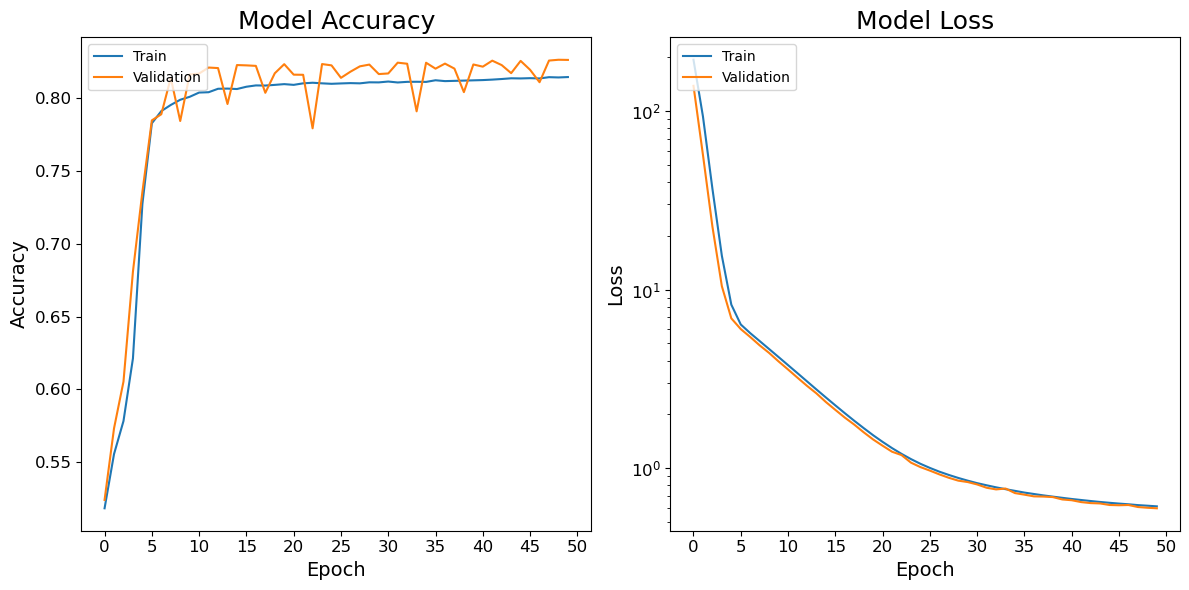

'/home/arsalan/wsu-grid/hm_jetscapeml_source/reports/figures/eloss_vgg16_net_1_fold_50_epoch_1200k_dataset_size_batch_128_no_rl_hm_srv3_cpu_24_mem_32gb/accuracy_loss.png'

In [6]:
# from jet_ml.evaluation import plot_training_history
plot_training_history(history=history,fold=None,loss_y_scale='log')

In [9]:
import matplotlib.pyplot as plt
import os
from jet_ml.config import Config

def plot_multiple_histories(histories, x_tick=5, loss_y_scale=None):
    """
    Plot multiple training and validation accuracy and loss plots in a 3x3 grid.

    Parameters:
    - histories (list): List of tf.keras.callbacks.History objects containing training/validation metrics.
    - x_tick (int): Steps in x-axis (default is 5).
    - loss_y_scale (str): Scaling for loss y-axis, e.g., 'log' for logarithmic scale.
    """
    # Increase font sizes globally
    plt.rcParams.update({
        'axes.titlesize': 18,       # Title font size
        'axes.labelsize': 14,       # Axis label font size
        'xtick.labelsize': 12,      # X-tick font size
        'ytick.labelsize': 12,      # Y-tick font size
    })

    fig, axs = plt.subplots(3, 3, figsize=(18, 18))
    axs = axs.flatten()  # Flatten to easily iterate through subplots

    for i, history in enumerate(histories):
        if i >= 9:
            break  # Stop if more than 9 histories

        # Accuracy plot (left subplot in each cell)
        ax1 = axs[i]
        x_axis_length = len(history.history.get('accuracy', [])) + 1
        ax1.plot(history.history.get('accuracy', []), label='Train Accuracy', color='blue')
        ax1.plot(history.history.get('val_accuracy', []), label='Val Accuracy', color='cyan')
        ax1.set_title(f'Model {i + 1} - Accuracy')
        ax1.set_xlabel('Epoch')
        ax1.set_ylabel('Accuracy')
        ax1.legend(loc='upper left', fontsize=8)
        ax1.set_xticks(range(0, x_axis_length, x_tick))

        # Loss plot (right subplot in each cell)
        ax2 = ax1.twinx()  # Share x-axis
        ax2.plot(history.history.get('loss', []), label='Train Loss', color='red')
        ax2.plot(history.history.get('val_loss', []), label='Val Loss', color='orange')
        if loss_y_scale:
            ax2.set_yscale(loss_y_scale)
        ax2.set_ylabel('Loss')
        ax2.legend(loc='upper right', fontsize=8)

    plt.tight_layout()
    
    # Save the plot with high resolution (300 dpi)
    file_name = os.path.join(Config().SIMULATION_FIGURES_DIR, 'accuracy_loss_grid.png')
    plt.savefig(file_name, dpi=300)
    plt.show()
    plt.close()

    return file_name

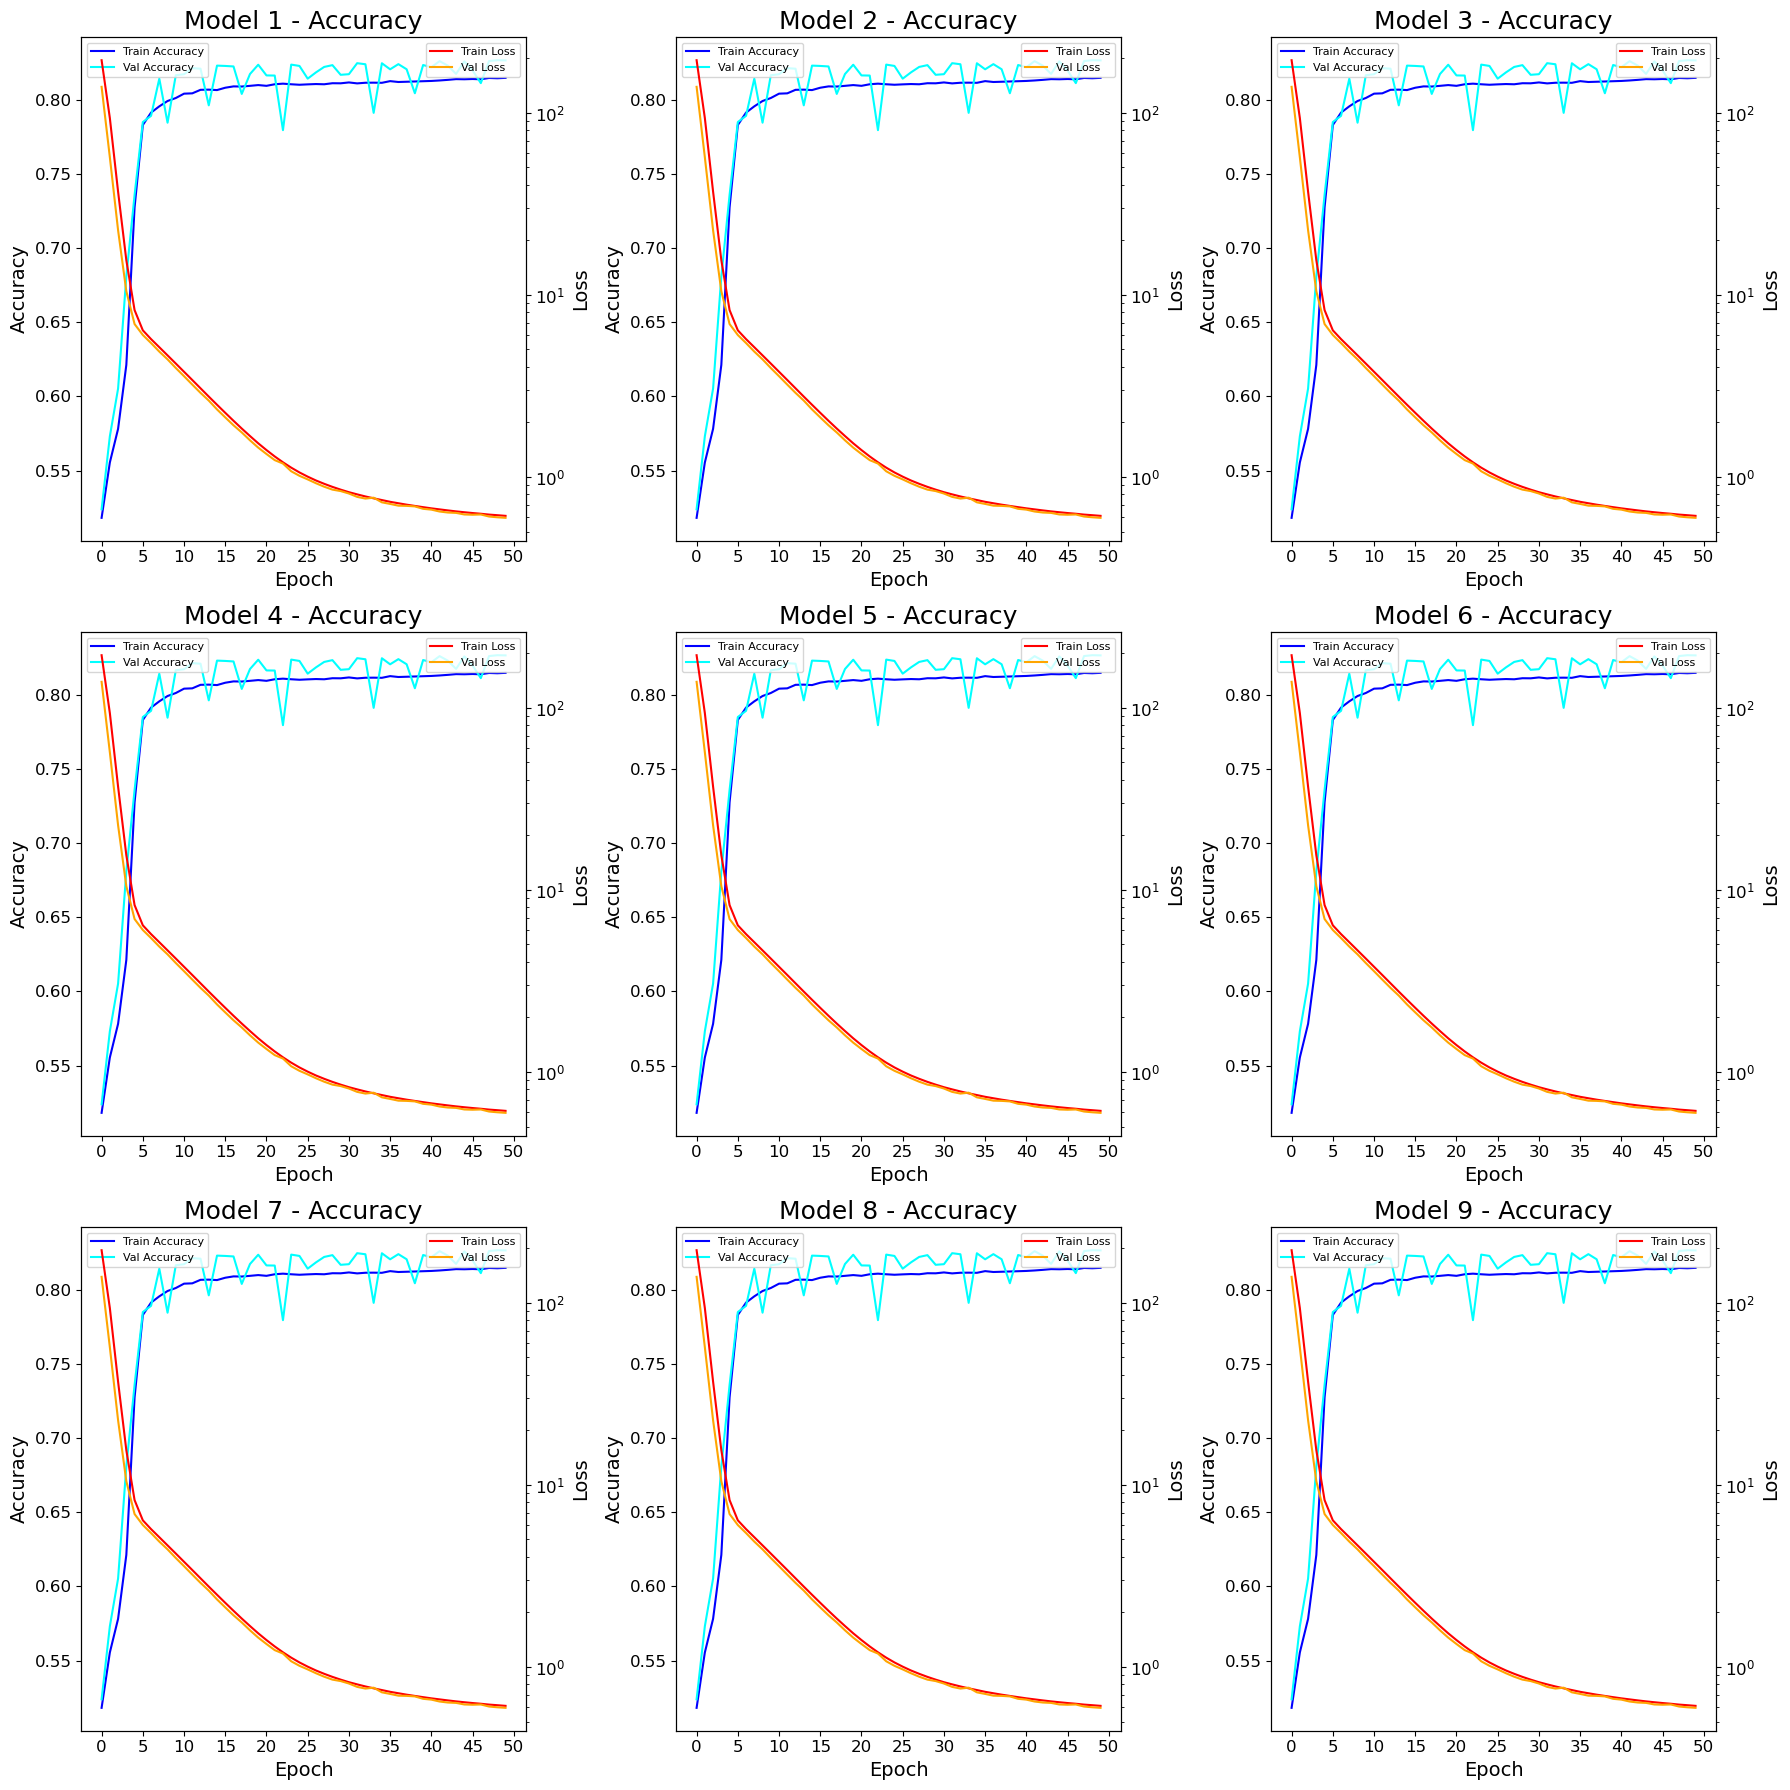

In [10]:
call = plot_multiple_histories(histories=[history, history, history, history, history, history, history, history, history], loss_y_scale='log')

In [67]:
import matplotlib.pyplot as plt
import os
from jet_ml.config import Config

def plot_multiple_histories_with_row_col_title(histories, row_titles=None, col_titles=None, x_tick=5, loss_y_scale=None):
    """
    Plot multiple training and validation accuracy and loss plots in a 3x3 grid with row and column titles.

    Parameters:
    - histories (list): List of tf.keras.callbacks.History objects containing training/validation metrics.
    - row_titles (list): Titles for each row in the grid.
    - col_titles (list): Titles for each column in the grid.
    - x_tick (int): Steps in x-axis (default is 5).
    - loss_y_scale (str): Scaling for loss y-axis, e.g., 'log' for logarithmic scale.
    """
    # Increase font sizes globally
    plt.rcParams.update({
        'axes.titlesize': 18,       # Title font size
        'axes.labelsize': 14,       # Axis label font size
        'xtick.labelsize': 12,      # X-tick font size
        'ytick.labelsize': 12,      # Y-tick font size
    })

    fig, axs = plt.subplots(3, 3, figsize=(18, 18))
    axs = axs.flatten()  # Flatten to easily iterate through subplots

    # Plot each history in a 3x3 grid
    for i, history in enumerate(histories):
        if i >= 9:
            break  # Stop if more than 9 histories

        # Accuracy plot (left subplot in each cell)
        ax1 = axs[i]
        x_axis_length = len(history.history.get('accuracy', [])) + 1
        # ax1.plot(history.history.get('accuracy', []), label='Train Accuracy', color='purple',marker='o', linestyle='-',markersize=5)
        # ax1.plot(history.history.get('val_accuracy', []), label='Val Accuracy', color='navy', marker='s',linestyle='--', markersize=5)
        ax1.plot(history.history.get('accuracy', []), label='Train Accuracy', marker='o', linestyle='-',markersize=5)
        ax1.plot(history.history.get('val_accuracy', []), label='Val Accuracy',  marker='s',linestyle='--', markersize=5)
        # ax1.set_title(f'Model {i + 1} - Accuracy')
        ax1.set_xlabel('Epoch')
        ax1.set_ylabel('Accuracy')
        # ax1.legend(loc='upper left', fontsize=8)
        # ax1.legend(loc='center right', fontsize=8)
        ax1.legend(loc='upper left', fontsize=10)
        ax1.set_xticks(range(0, x_axis_length, x_tick))

        # Loss plot (right subplot in each cell)
        ax2 = ax1.twinx()  # Share x-axis
        # ax2.plot(history.history.get('loss', []), label='Train Loss', color='red', marker='^',linestyle='-', markersize=4)
        # ax2.plot(history.history.get('val_loss', []), label='Val Loss', color='orange', marker='d',linestyle='--', markersize=4)
        ax2.plot(history.history.get('loss', []), label='Train Loss',  marker='^',linestyle='-', markersize=4)
        ax2.plot(history.history.get('val_loss', []), label='Val Loss',  marker='d',linestyle='--', markersize=4)
        if loss_y_scale:
            ax2.set_yscale(loss_y_scale)
        ax2.set_ylabel('Loss')
        # ax2.legend(loc='upper right', fontsize=8)
        # ax2.legend(loc='lower left', fontsize=8)
        ax2.legend(loc='upper right', fontsize=10)


    # Add column titles
    if col_titles:
        for col, title in enumerate(col_titles):
            fig.text(0.25 + col * 0.25, 0.92, title, ha='center', va='center', fontsize=20)

    # Add row titles
    if row_titles:
        for row, title in enumerate(row_titles):
            fig.text(0.08, 0.75 - row * 0.25, title, ha='center', va='center', rotation='vertical', fontsize=20)

    plt.tight_layout(rect=[0.1, 0.1, 0.9, 0.9])  # Adjust layout to fit titles

    # Save the plot with high resolution (300 dpi)
    file_name = os.path.join(Config().SIMULATION_FIGURES_DIR, 'accuracy_loss_grid.png')
    plt.savefig(file_name, dpi=300)
    plt.show()
    plt.close()

    return file_name

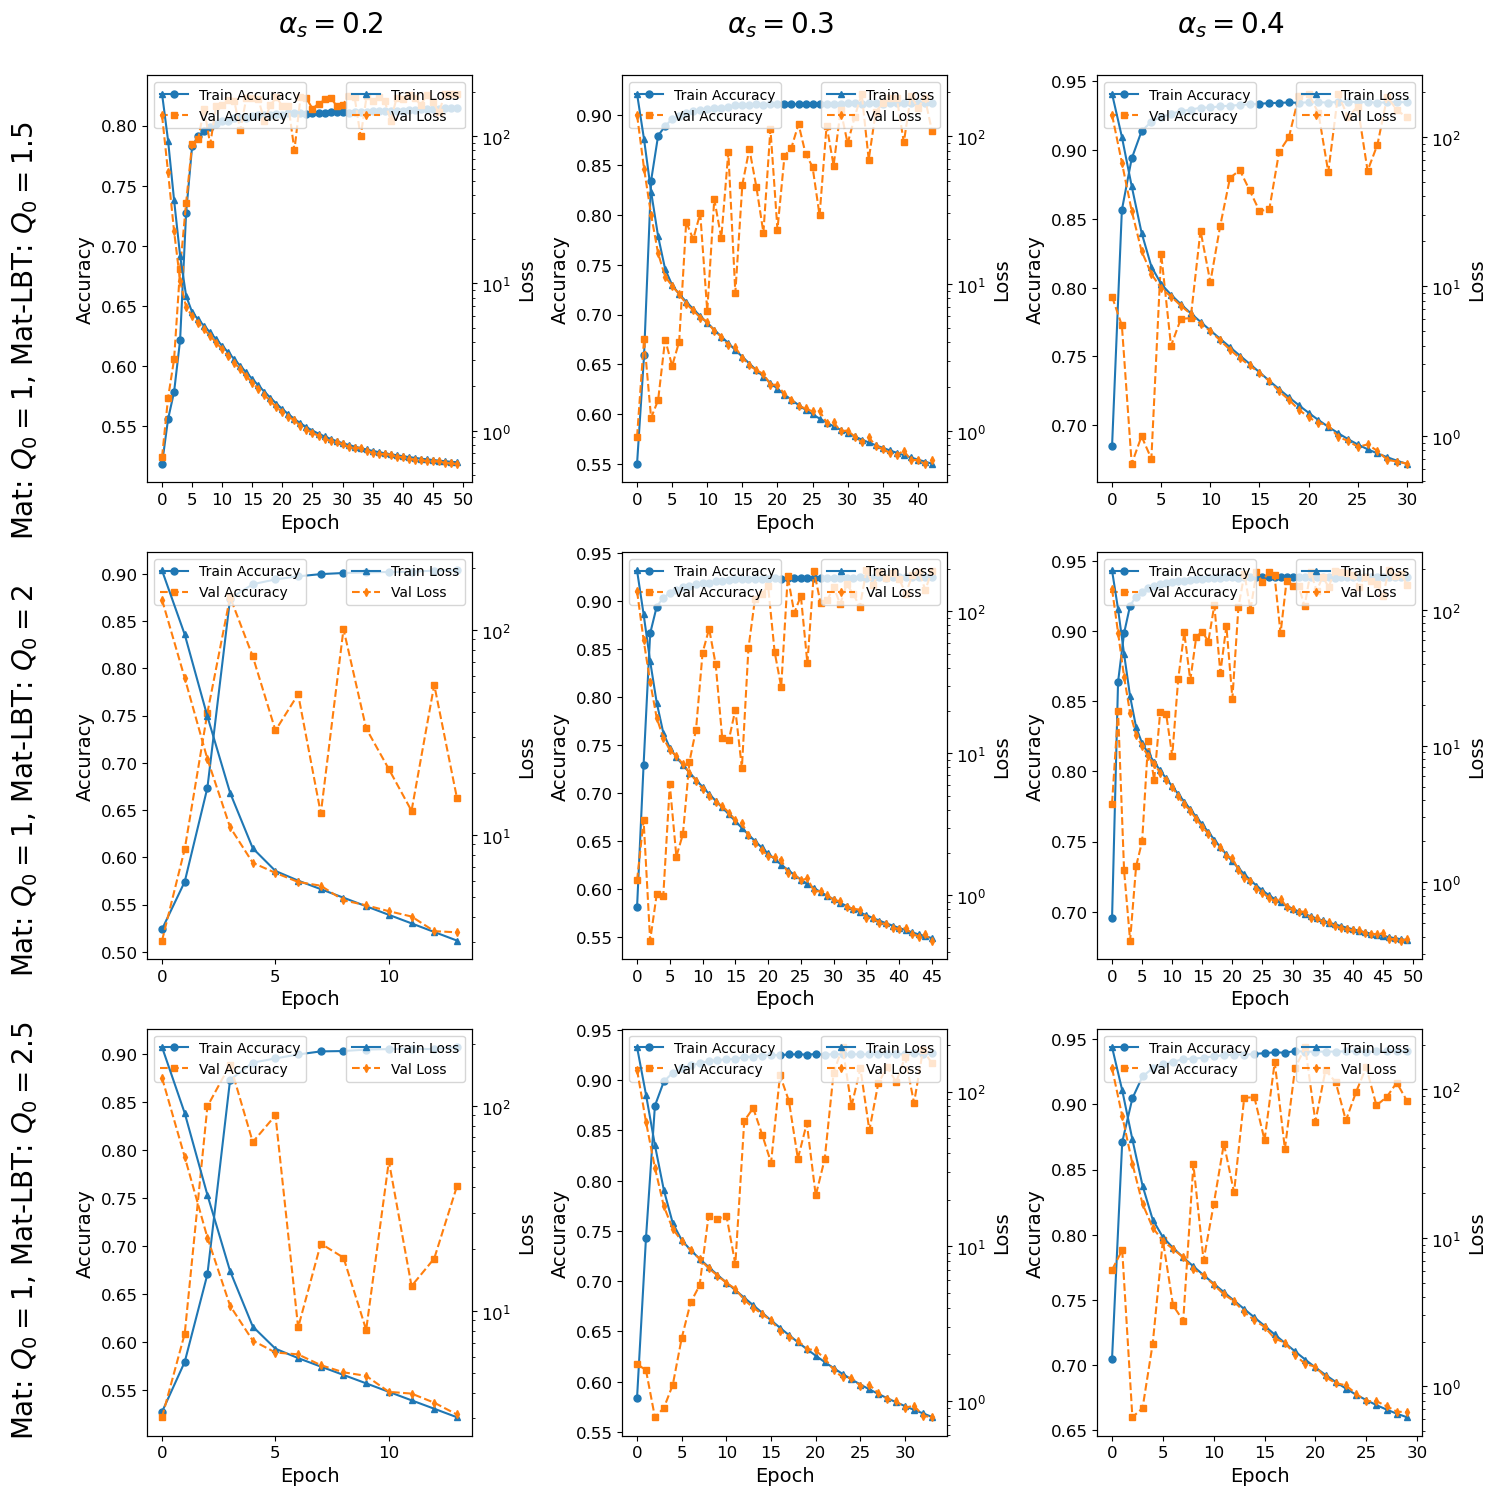

'/home/arsalan/wsu-grid/hm_jetscapeml_source/reports/figures/eloss_vgg16_net_1_fold_50_epoch_1200k_dataset_size_batch_128_no_rl_hm_srv3_cpu_24_mem_32gb/accuracy_loss_grid.png'

In [68]:
row_titles = [
    r"Mat: $Q_0=1$, Mat-LBT: $Q_0=1.5$",
    r"Mat: $Q_0=1$, Mat-LBT: $Q_0=2$",
    r"Mat: $Q_0=1$, Mat-LBT: $Q_0=2.5$"
]
col_titles = [r"$\alpha_s = 0.2$", r"$\alpha_s = 0.3$", r"$\alpha_s = 0.4$"]
plot_multiple_histories_with_row_col_title (histories=histories, row_titles=row_titles, col_titles=col_titles, loss_y_scale='log')

In [79]:
import matplotlib.pyplot as plt
import os
from jet_ml.config import Config
from cycler import cycler


def plot_multiple_histories_with_row_col_title(histories, row_titles=None, col_titles=None, x_tick=5, loss_y_scale=None):
    """
    Plot multiple training and validation accuracy and loss plots in a 3x3 grid with row and column titles.

    Parameters:
    - histories (list): List of tf.keras.callbacks.History objects containing training/validation metrics.
    - row_titles (list): Titles for each row in the grid.
    - col_titles (list): Titles for each column in the grid.
    - x_tick (int): Steps in x-axis (default is 5).
    - loss_y_scale (str): Scaling for loss y-axis, e.g., 'log' for logarithmic scale.
    """
    # Increase font sizes globally
    plt.rcParams.update({
        'axes.titlesize': 18,       # Title font size
        'axes.labelsize': 14,       # Axis label font size
        'xtick.labelsize': 12,      # X-tick font size
        'ytick.labelsize': 12,      # Y-tick font size,
    })

    fig, axs = plt.subplots(3, 3, figsize=(18, 18))
    axs = axs.flatten()  # Flatten to easily iterate through subplots

    # Plot each history in a 3x3 grid
    for i, history in enumerate(histories):
        if i >= 9:
            break  # Stop if more than 9 histories

        # Accuracy plot
        ax1 = axs[i]
        x_axis_length = len(history.history.get('accuracy', [])) + 1
        ax1.plot(history.history.get('accuracy', []), label='Train Accuracy', marker='o', linestyle='-', markersize=5)
        ax1.plot(history.history.get('val_accuracy', []), label='Val Accuracy', marker='s', linestyle='--', markersize=5)
        ax1.set_xlabel('Epoch')
        ax1.set_ylabel('Accuracy')
        ax1.legend(loc='center right', fontsize=10)
        ax1.set_xticks(range(0, x_axis_length, x_tick))

        # Loss plot
        ax2 = ax1.twinx()  # Share x-axis
        ax2.set_prop_cycle(cycler('color', plt.rcParams['axes.prop_cycle'].by_key()['color'][2:]))

        ax2.plot(history.history.get('loss', []), label='Train Loss', marker='^', linestyle='-', markersize=4)
        ax2.plot(history.history.get('val_loss', []), label='Val Loss', marker='d', linestyle='--', markersize=4)
        if loss_y_scale:
            ax2.set_yscale(loss_y_scale)
        ax2.set_ylabel('Loss')
        ax2.legend(loc='center right', fontsize=10)

    # Add column titles
    if col_titles:
        for col, title in enumerate(col_titles):
            fig.text(0.25 + col * 0.25, 0.92, title, ha='center', va='center', fontsize=20)

    # Add row titles
    if row_titles:
        for row, title in enumerate(row_titles):
            fig.text(0.08, 0.75 - row * 0.25, title, ha='center', va='center', rotation='vertical', fontsize=20)

    plt.tight_layout(rect=[0.1, 0.1, 0.9, 0.9])  # Adjust layout to fit titles

    # Save the plot with high resolution (300 dpi)
    file_name = os.path.join(Config().SIMULATION_FIGURES_DIR, 'accuracy_loss_grid.png')
    plt.savefig(file_name, dpi=300)
    plt.show()
    plt.close()

    return file_name


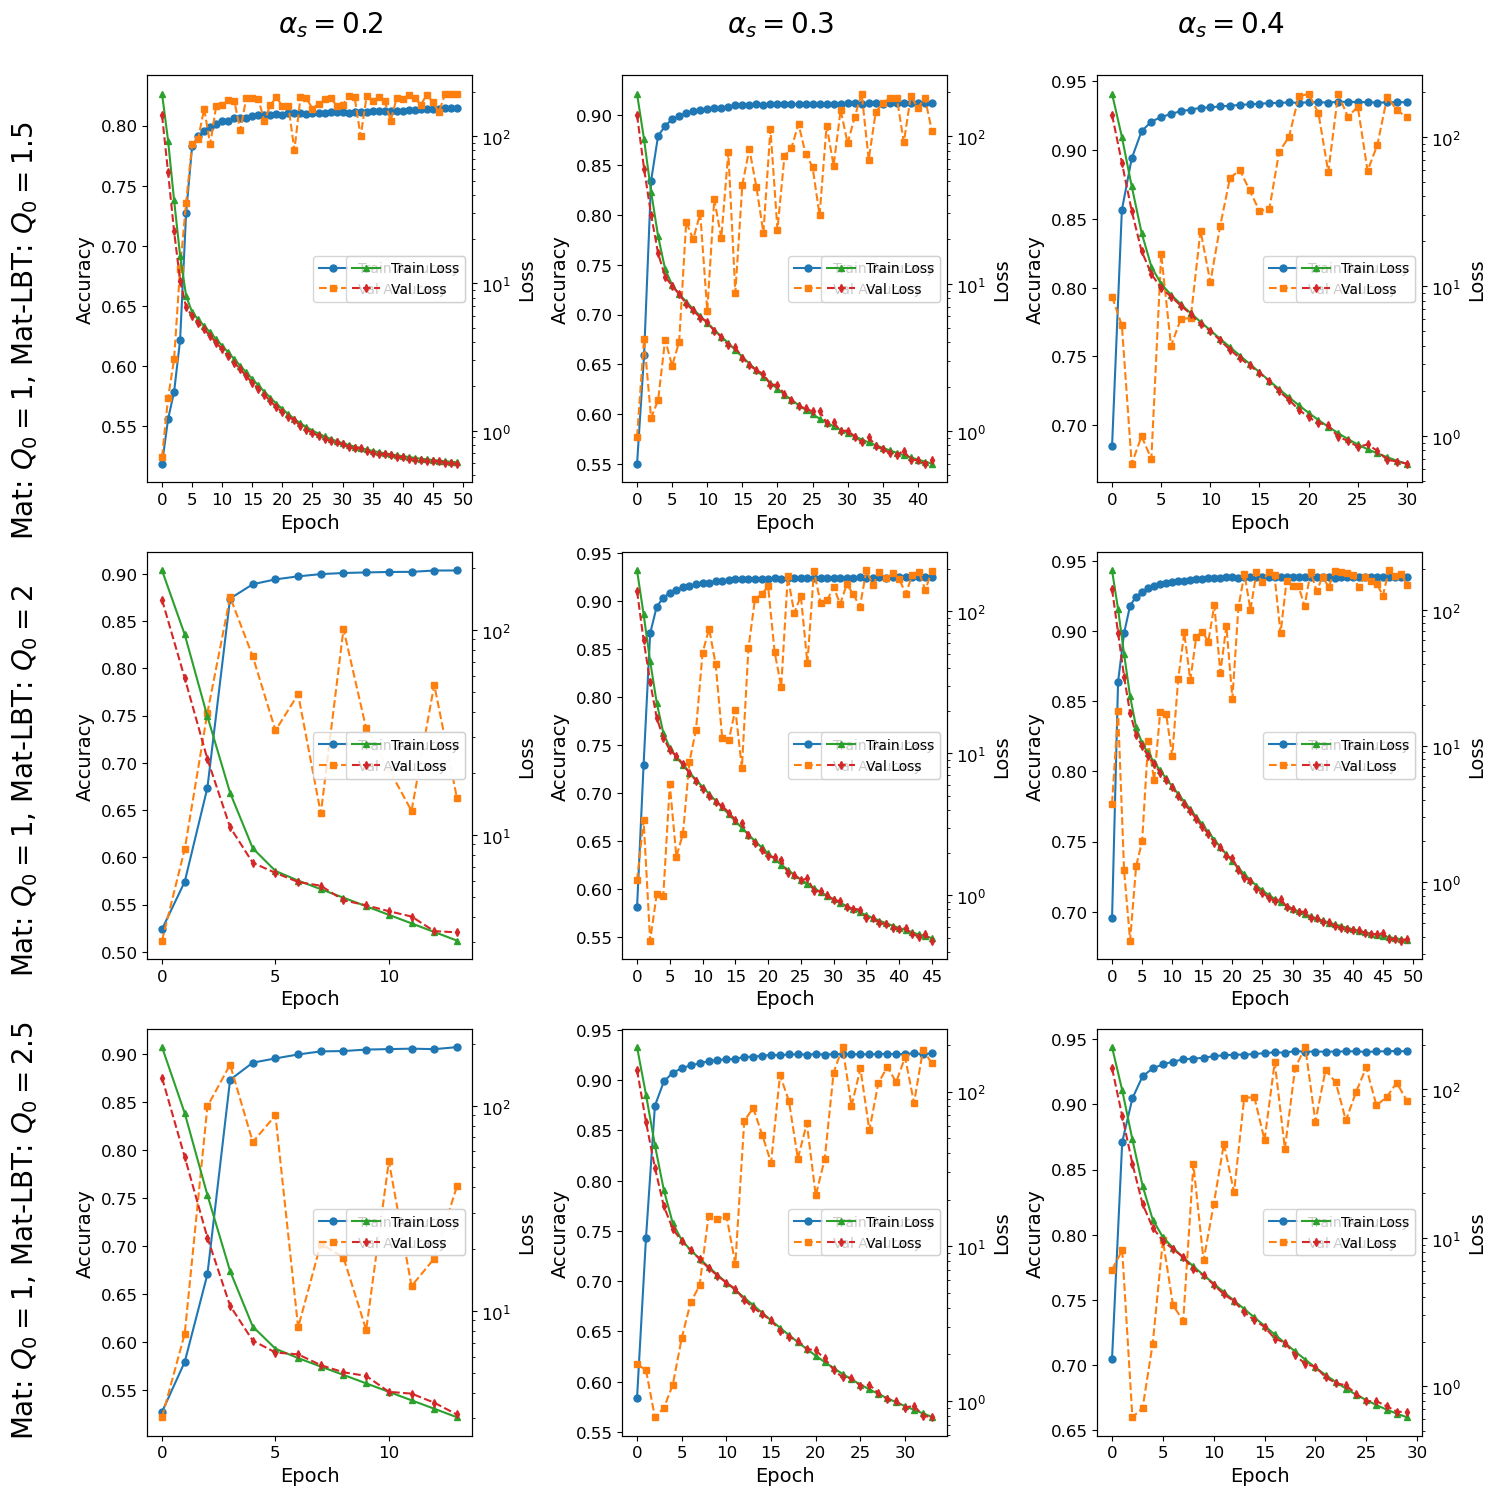

'/home/arsalan/wsu-grid/hm_jetscapeml_source/reports/figures/eloss_vgg16_net_1_fold_50_epoch_1200k_dataset_size_batch_128_no_rl_hm_srv3_cpu_24_mem_32gb/accuracy_loss_grid.png'

In [80]:
row_titles = [
    r"Mat: $Q_0=1$, Mat-LBT: $Q_0=1.5$",
    r"Mat: $Q_0=1$, Mat-LBT: $Q_0=2$",
    r"Mat: $Q_0=1$, Mat-LBT: $Q_0=2.5$"
]
col_titles = [r"$\alpha_s = 0.2$", r"$\alpha_s = 0.3$", r"$\alpha_s = 0.4$"]
plot_multiple_histories_with_row_col_title (histories=histories, row_titles=row_titles, col_titles=col_titles, loss_y_scale='log')

In [113]:
import matplotlib.pyplot as plt
import os
from jet_ml.config import Config
from cycler import cycler

def plot_multiple_histories_with_row_col_title(histories, row_titles=None, col_titles=None, x_tick=5, loss_y_scale=None):
    """
    Plot multiple training and validation accuracy and loss plots in a 3x3 grid with row and column titles.

    Parameters:
    - histories (list): List of tf.keras.callbacks.History objects containing training/validation metrics.
    - row_titles (list): Titles for each row in the grid.
    - col_titles (list): Titles for each column in the grid.
    - x_tick (int): Steps in x-axis (default is 5).
    - loss_y_scale (str): Scaling for loss y-axis, e.g., 'log' for logarithmic scale.
    """
    # Increase font sizes globally
    plt.rcParams.update({
        'axes.titlesize': 18,       # Title font size
        'axes.labelsize': 14,       # Axis label font size
        'xtick.labelsize': 12,      # X-tick font size
        'ytick.labelsize': 12,      # Y-tick font size,
    })

    fig, axs = plt.subplots(3, 3, figsize=(18, 18))
    axs = axs.flatten()  # Flatten to easily iterate through subplots

    # Plot each history in a 3x3 grid
    for i, history in enumerate(histories):
        if i >= 9:
            break  # Stop if more than 9 histories

        # Accuracy plot
        ax1 = axs[i]
        x_axis_length = len(history.history.get('accuracy', [])) + 1
        ax1.plot(history.history.get('accuracy', []), label='Train Accuracy', marker='o', linestyle='-', markersize=5)
        ax1.plot(history.history.get('val_accuracy', []), label='Val Accuracy', marker='s', linestyle='--', markersize=5)
        ax1.set_xlabel('Epoch')
        ax1.set_ylabel('Accuracy')
        ax1.set_xticks(range(0, x_axis_length, x_tick))

        # Loss plot
        ax2 = ax1.twinx()  # Share x-axis
        ax2.set_prop_cycle(cycler('color', plt.rcParams['axes.prop_cycle'].by_key()['color'][2:]))
        ax2.plot(history.history.get('loss', []), label='Train Loss', marker='^', linestyle='-', markersize=4)
        ax2.plot(history.history.get('val_loss', []), label='Val Loss', marker='d', linestyle='--', markersize=4)
        if loss_y_scale:
            ax2.set_yscale(loss_y_scale)
        ax2.set_ylabel('Loss')

        # Place the legends outside the plot to the right (center right)
        ax1.legend(loc='center left', bbox_to_anchor=(0.5, 0.45), fontsize=10, frameon=True, ncol=1)
        ax2.legend(loc='center left', bbox_to_anchor=(0.6, 0.3), fontsize=10, frameon=True, ncol=1)

    # Add column titles
    if col_titles:
        for col, title in enumerate(col_titles):
            fig.text(0.25 + col * 0.25, 0.92, title, ha='center', va='center', fontsize=20)

    # Add row titles
    if row_titles:
        for row, title in enumerate(row_titles):
            fig.text(0.08, 0.77 - row * 0.25, title, ha='center', va='center', rotation='vertical', fontsize=20)

    # Adjust layout to fit titles and avoid overlap
    plt.tight_layout(rect=[0.1, 0.1, 0.9, 0.9])  # Ensure room for the legends outside

    # Save the plot with high resolution (300 dpi)
    file_name = os.path.join(Config().SIMULATION_FIGURES_DIR, 'accuracy_loss_grid.png')
    plt.savefig(file_name, dpi=300, bbox_inches='tight')  # Include legends outside the plot
    plt.show()
    plt.close()

    return file_name


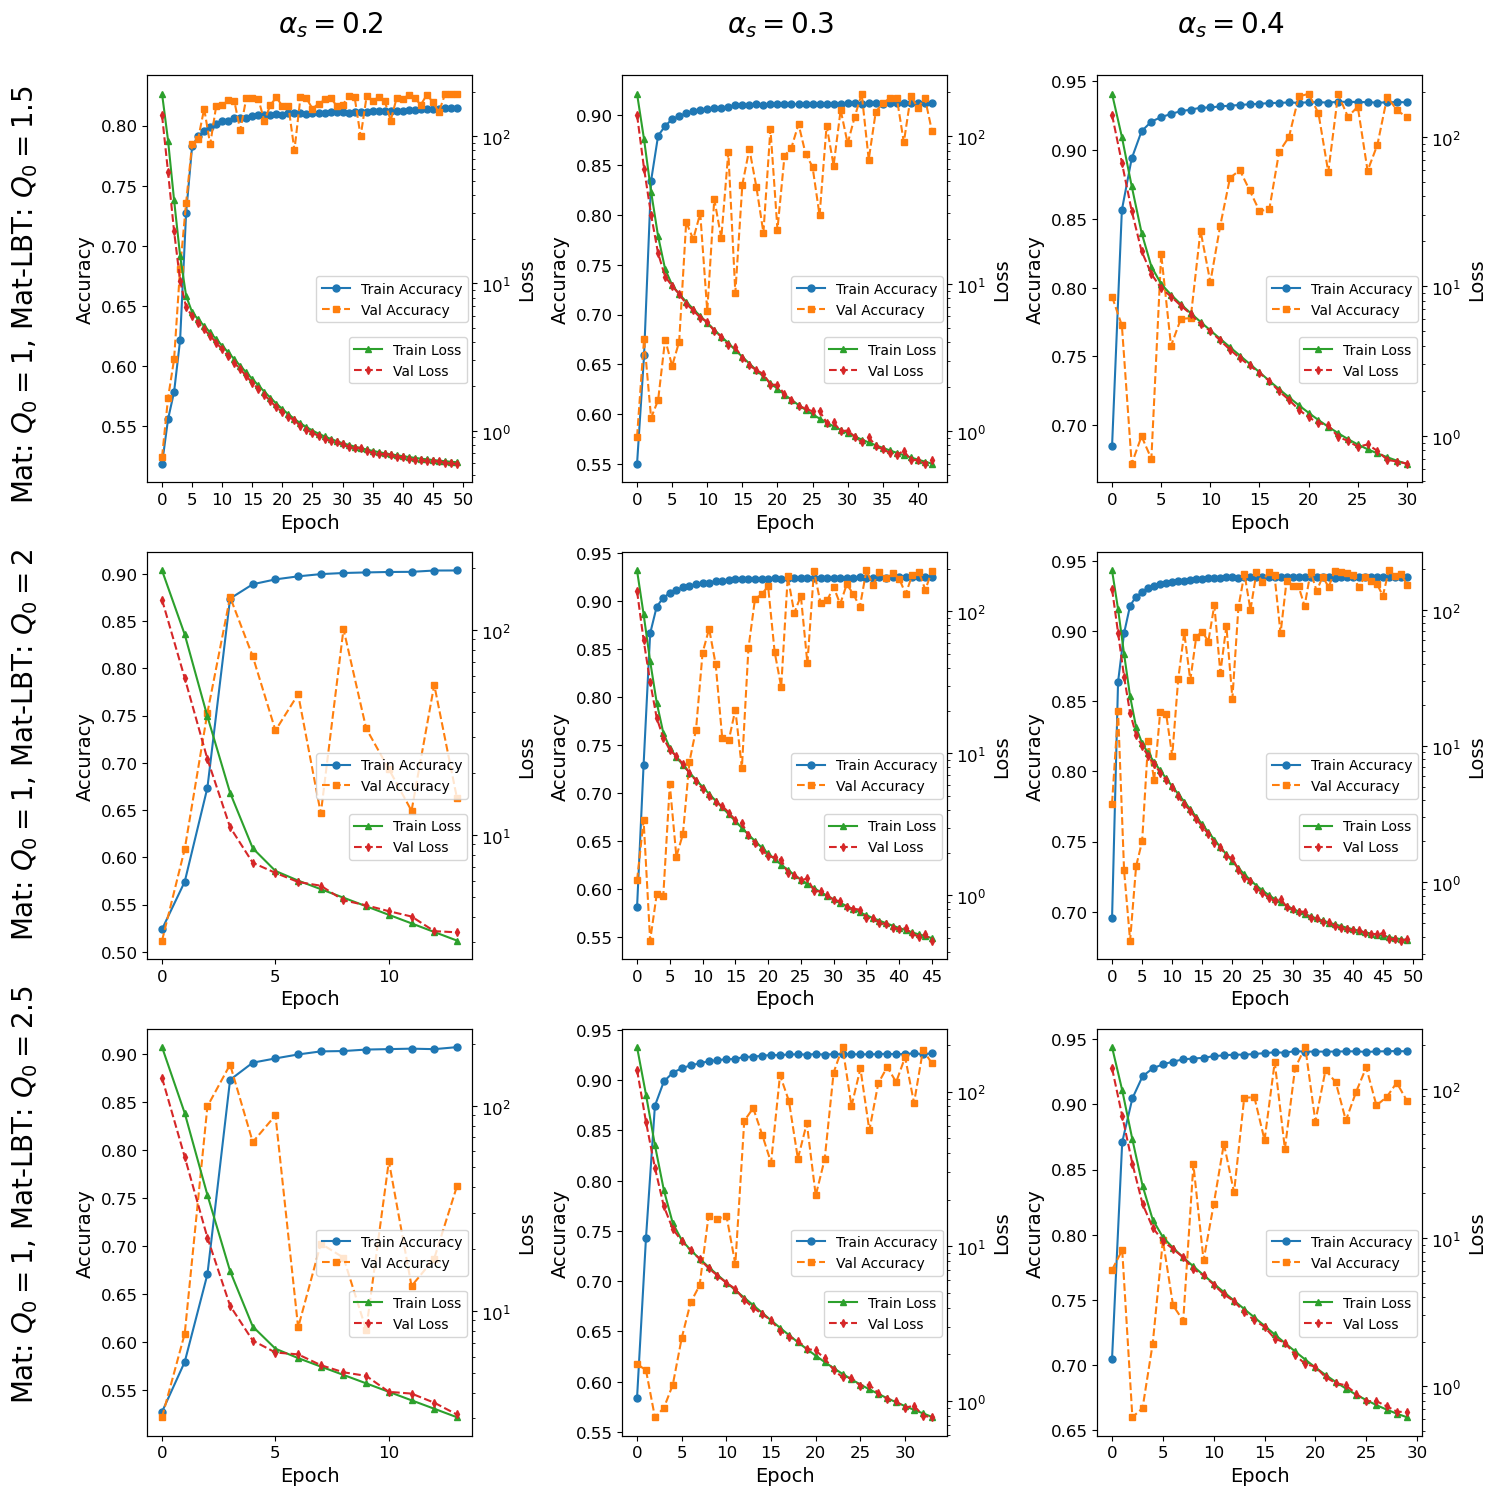

'/home/arsalan/wsu-grid/hm_jetscapeml_source/reports/figures/eloss_vgg16_net_1_fold_50_epoch_1200k_dataset_size_batch_128_no_rl_hm_srv3_cpu_24_mem_32gb/accuracy_loss_grid.png'

In [114]:
row_titles = [
    r"Mat: $Q_0=1$, Mat-LBT: $Q_0=1.5$",
    r"Mat: $Q_0=1$, Mat-LBT: $Q_0=2$",
    r"Mat: $Q_0=1$, Mat-LBT: $Q_0=2.5$"
]
col_titles = [r"$\alpha_s = 0.2$", r"$\alpha_s = 0.3$", r"$\alpha_s = 0.4$"]
plot_multiple_histories_with_row_col_title (histories=histories, row_titles=row_titles, col_titles=col_titles, loss_y_scale='log')

In [73]:
import matplotlib.pyplot as plt
import os
from jet_ml.config import Config
from cycler import cycler

def plot_multiple_histories_with_row_col_title(histories, row_titles=None, col_titles=None, x_tick=5, loss_y_scale=None):
    """
    Plot multiple training and validation accuracy and loss plots in a 3x3 grid with row and column titles.

    Parameters:
    - histories (list): List of tf.keras.callbacks.History objects containing training/validation metrics.
    - row_titles (list): Titles for each row in the grid.
    - col_titles (list): Titles for each column in the grid.
    - x_tick (int): Steps in x-axis (default is 5).
    - loss_y_scale (str): Scaling for loss y-axis, e.g., 'log' for logarithmic scale.
    """
    # Increase font sizes globally
    plt.rcParams.update({
        'axes.titlesize': 18,       # Title font size
        'axes.labelsize': 14,       # Axis label font size
        'xtick.labelsize': 12,      # X-tick font size
        'ytick.labelsize': 12,      # Y-tick font size,
    })

    fig, axs = plt.subplots(3, 3, figsize=(18, 18))
    axs = axs.flatten()  # Flatten to easily iterate through subplots

    for i, history in enumerate(histories):
        if i >= 9:
            break  # Stop if more than 9 histories

        # Accuracy plot
        ax1 = axs[i]
        x_axis_length = len(history.history.get('accuracy', [])) + 1

        # Use the default color cycle
        ax1.plot(history.history.get('accuracy', []), label='Train Accuracy', marker='o', linestyle='-', markersize=5)
        ax1.plot(history.history.get('val_accuracy', []), label='Val Accuracy', marker='s', linestyle='--', markersize=5)
        ax1.set_xlabel('Epoch')
        ax1.set_ylabel('Accuracy')
        ax1.set_xticks(range(0, x_axis_length, x_tick))

        # Position accuracy legend in the top-left empty space
        ax1.legend(
            loc='upper left',
            bbox_to_anchor=(0, 1.1),
            fontsize=10,
            frameon=False
        )

        # Loss plot (skip first two colors)
        ax2 = ax1.twinx()  # Share x-axis
        ax2.set_prop_cycle(cycler('color', plt.rcParams['axes.prop_cycle'].by_key()['color'][2:]))
        ax2.plot(history.history.get('loss', []), label='Train Loss', marker='^', linestyle='-', markersize=4)
        ax2.plot(history.history.get('val_loss', []), label='Val Loss', marker='d', linestyle='--', markersize=4)
        if loss_y_scale:
            ax2.set_yscale(loss_y_scale)
        ax2.set_ylabel('Loss')

        # Position loss legend in the bottom-right empty space
        ax2.legend(
            loc='lower right',
            bbox_to_anchor=(1, -0.15),
            fontsize=10,
            frameon=False
        )

    # Add column titles
    if col_titles:
        for col, title in enumerate(col_titles):
            fig.text(0.25 + col * 0.25, 0.92, title, ha='center', va='center', fontsize=20)

    # Add row titles
    if row_titles:
        for row, title in enumerate(row_titles):
            fig.text(0.08, 0.75 - row * 0.25, title, ha='center', va='center', rotation='vertical', fontsize=20)

    plt.tight_layout(rect=[0.1, 0.1, 0.9, 0.9])  # Adjust layout to fit titles

    # Save the plot with high resolution (300 dpi)
    file_name = os.path.join(Config().SIMULATION_FIGURES_DIR, 'accuracy_loss_grid.png')
    plt.savefig(file_name, dpi=300)
    plt.show()
    plt.close()

    return file_name


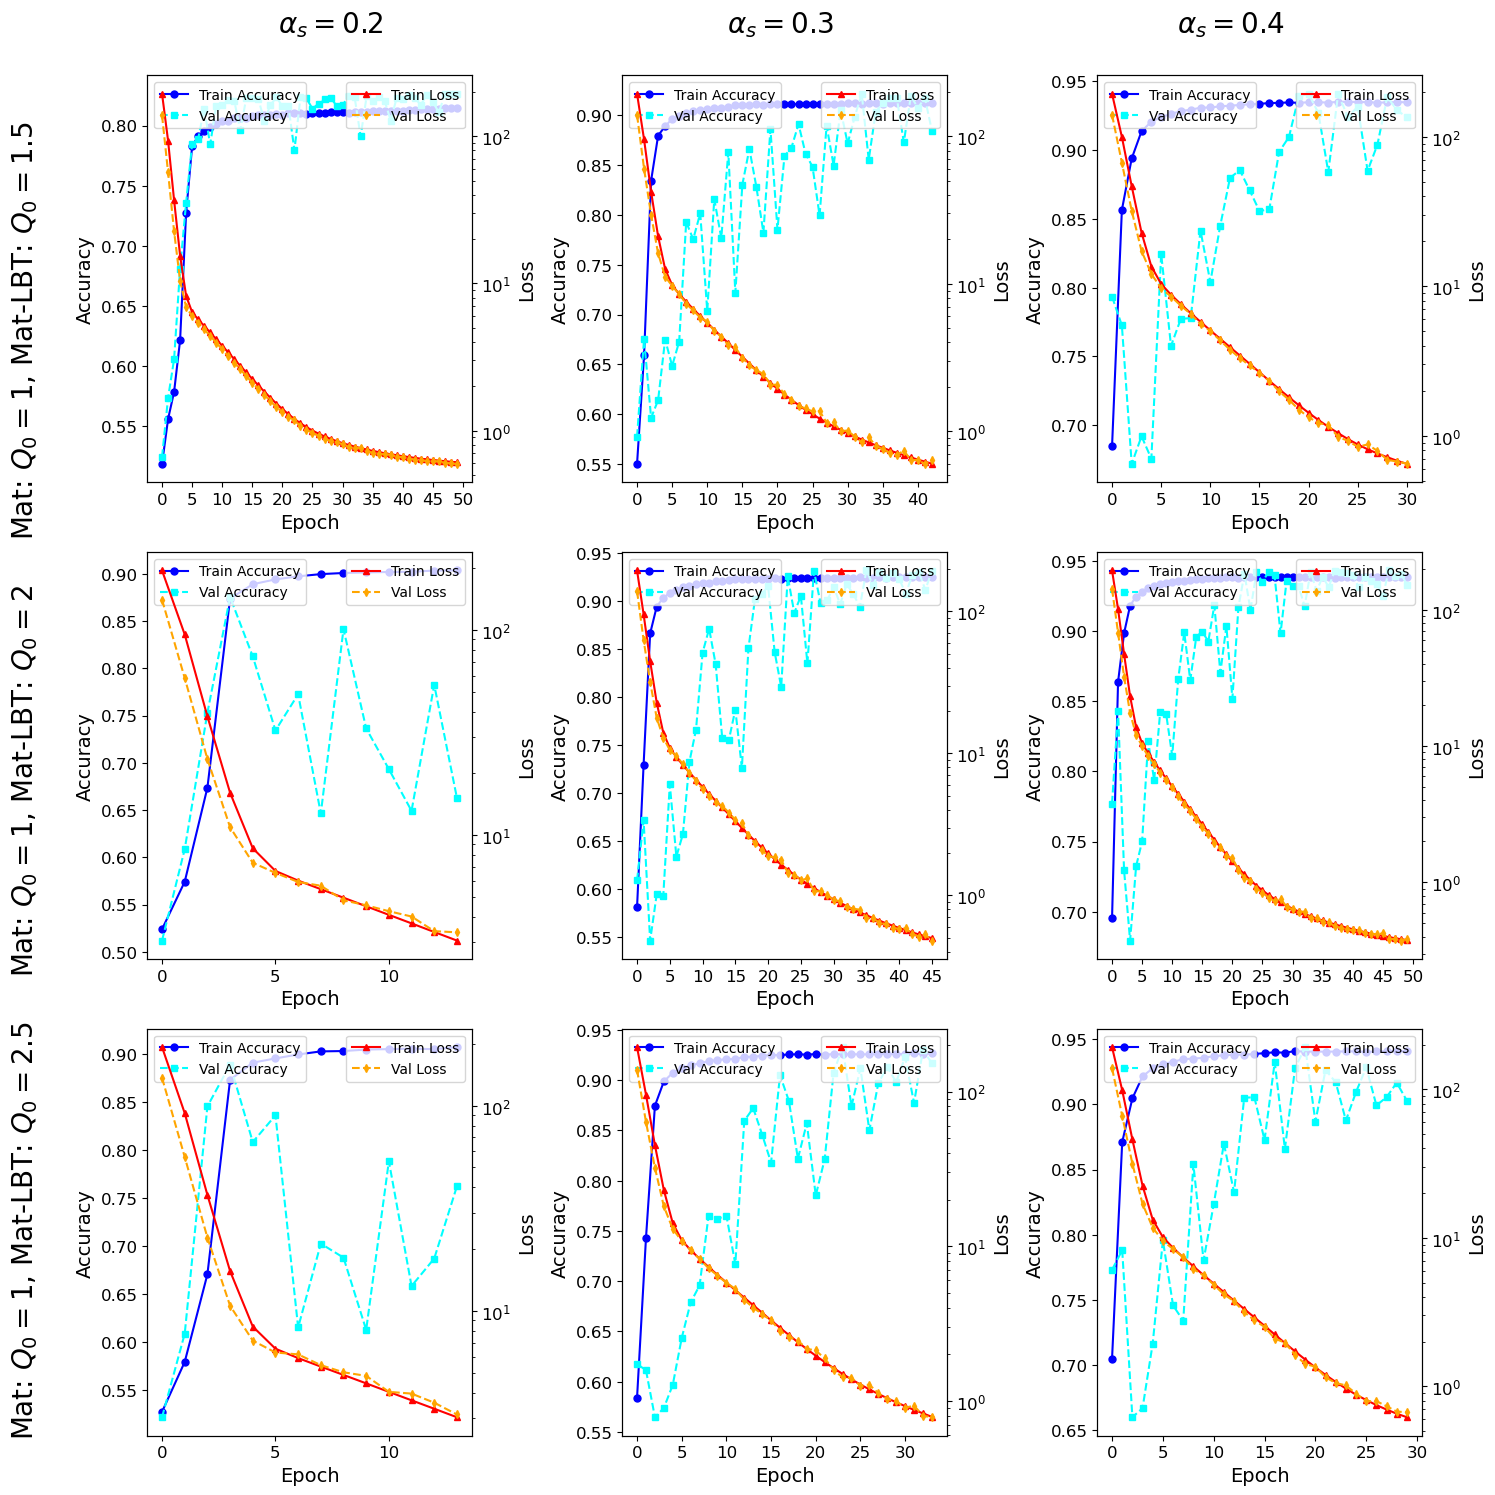

'/home/arsalan/wsu-grid/hm_jetscapeml_source/reports/figures/eloss_vgg16_net_1_fold_50_epoch_1200k_dataset_size_batch_128_no_rl_hm_srv3_cpu_24_mem_32gb/accuracy_loss_grid.png'

In [60]:
row_titles = [
    r"Mat: $Q_0=1$, Mat-LBT: $Q_0=1.5$",
    r"Mat: $Q_0=1$, Mat-LBT: $Q_0=2$",
    r"Mat: $Q_0=1$, Mat-LBT: $Q_0=2.5$"
]
col_titles = [r"$\alpha_s = 0.2$", r"$\alpha_s = 0.3$", r"$\alpha_s = 0.4$"]
plot_multiple_histories_with_row_col_title (histories=histories, row_titles=row_titles, col_titles=col_titles, loss_y_scale='log')

In [57]:
import matplotlib.pyplot as plt
import os
from jet_ml.config import Config

def plot_multiple_histories_with_row_col_title(histories, row_titles=None, col_titles=None, x_tick=5, loss_y_scale=None):
    """
    Plot multiple training and validation accuracy and loss plots in a 3x3 grid with row and column titles.

    Parameters:
    - histories (list): List of tf.keras.callbacks.History objects containing training/validation metrics.
    - row_titles (list): Titles for each row in the grid.
    - col_titles (list): Titles for each column in the grid.
    - x_tick (int): Steps in x-axis (default is 5).
    - loss_y_scale (str): Scaling for loss y-axis, e.g., 'log' for logarithmic scale.
    """
    # Increase font sizes globally
    plt.rcParams.update({
        'axes.titlesize': 18,       # Title font size
        'axes.labelsize': 14,       # Axis label font size
        'xtick.labelsize': 12,      # X-tick font size
        'ytick.labelsize': 12,      # Y-tick font size,
    })

    fig, axs = plt.subplots(3, 3, figsize=(18, 18))
    axs = axs.flatten()  # Flatten to easily iterate through subplots

    # Plot each history in a 3x3 grid
    for i, history in enumerate(histories):
        if i >= 9:
            break  # Stop if more than 9 histories

        # Accuracy plot
        ax1 = axs[i]
        x_axis_length = len(history.history.get('accuracy', [])) + 1
        ax1.plot(history.history.get('accuracy', []), 
                 label='Train Accuracy', color='black', marker='o', linestyle='-', markersize=5)
        ax1.plot(history.history.get('val_accuracy', []), 
                 label='Val Accuracy', color='black', marker='s', linestyle='--', markersize=5)
        ax1.set_xlabel('Epoch')
        ax1.set_ylabel('Accuracy')
        ax1.legend(loc='upper left', fontsize=10)
        ax1.set_xticks(range(0, x_axis_length, x_tick))

        # Loss plot
        ax2 = ax1.twinx()  # Share x-axis
        ax2.plot(history.history.get('loss', []), 
                 label='Train Loss', color='gray', marker='^', linestyle='-', markersize=5)
        ax2.plot(history.history.get('val_loss', []), 
                 label='Val Loss', color='gray', marker='d', linestyle='--', markersize=5)
        if loss_y_scale:
            ax2.set_yscale(loss_y_scale)
        ax2.set_ylabel('Loss')
        ax2.legend(loc='upper right', fontsize=10)

    # Add column titles
    if col_titles:
        for col, title in enumerate(col_titles):
            fig.text(0.25 + col * 0.25, 0.92, title, ha='center', va='center', fontsize=20)

    # Add row titles
    if row_titles:
        for row, title in enumerate(row_titles):
            fig.text(0.08, 0.75 - row * 0.25, title, ha='center', va='center', rotation='vertical', fontsize=20)

    plt.tight_layout(rect=[0.1, 0.1, 0.9, 0.9])  # Adjust layout to fit titles

    # Save the plot with high resolution (300 dpi)
    file_name = os.path.join(Config().SIMULATION_FIGURES_DIR, 'accuracy_loss_grid_bw.png')
    plt.savefig(file_name, dpi=300)
    plt.show()
    plt.close()

    return file_name


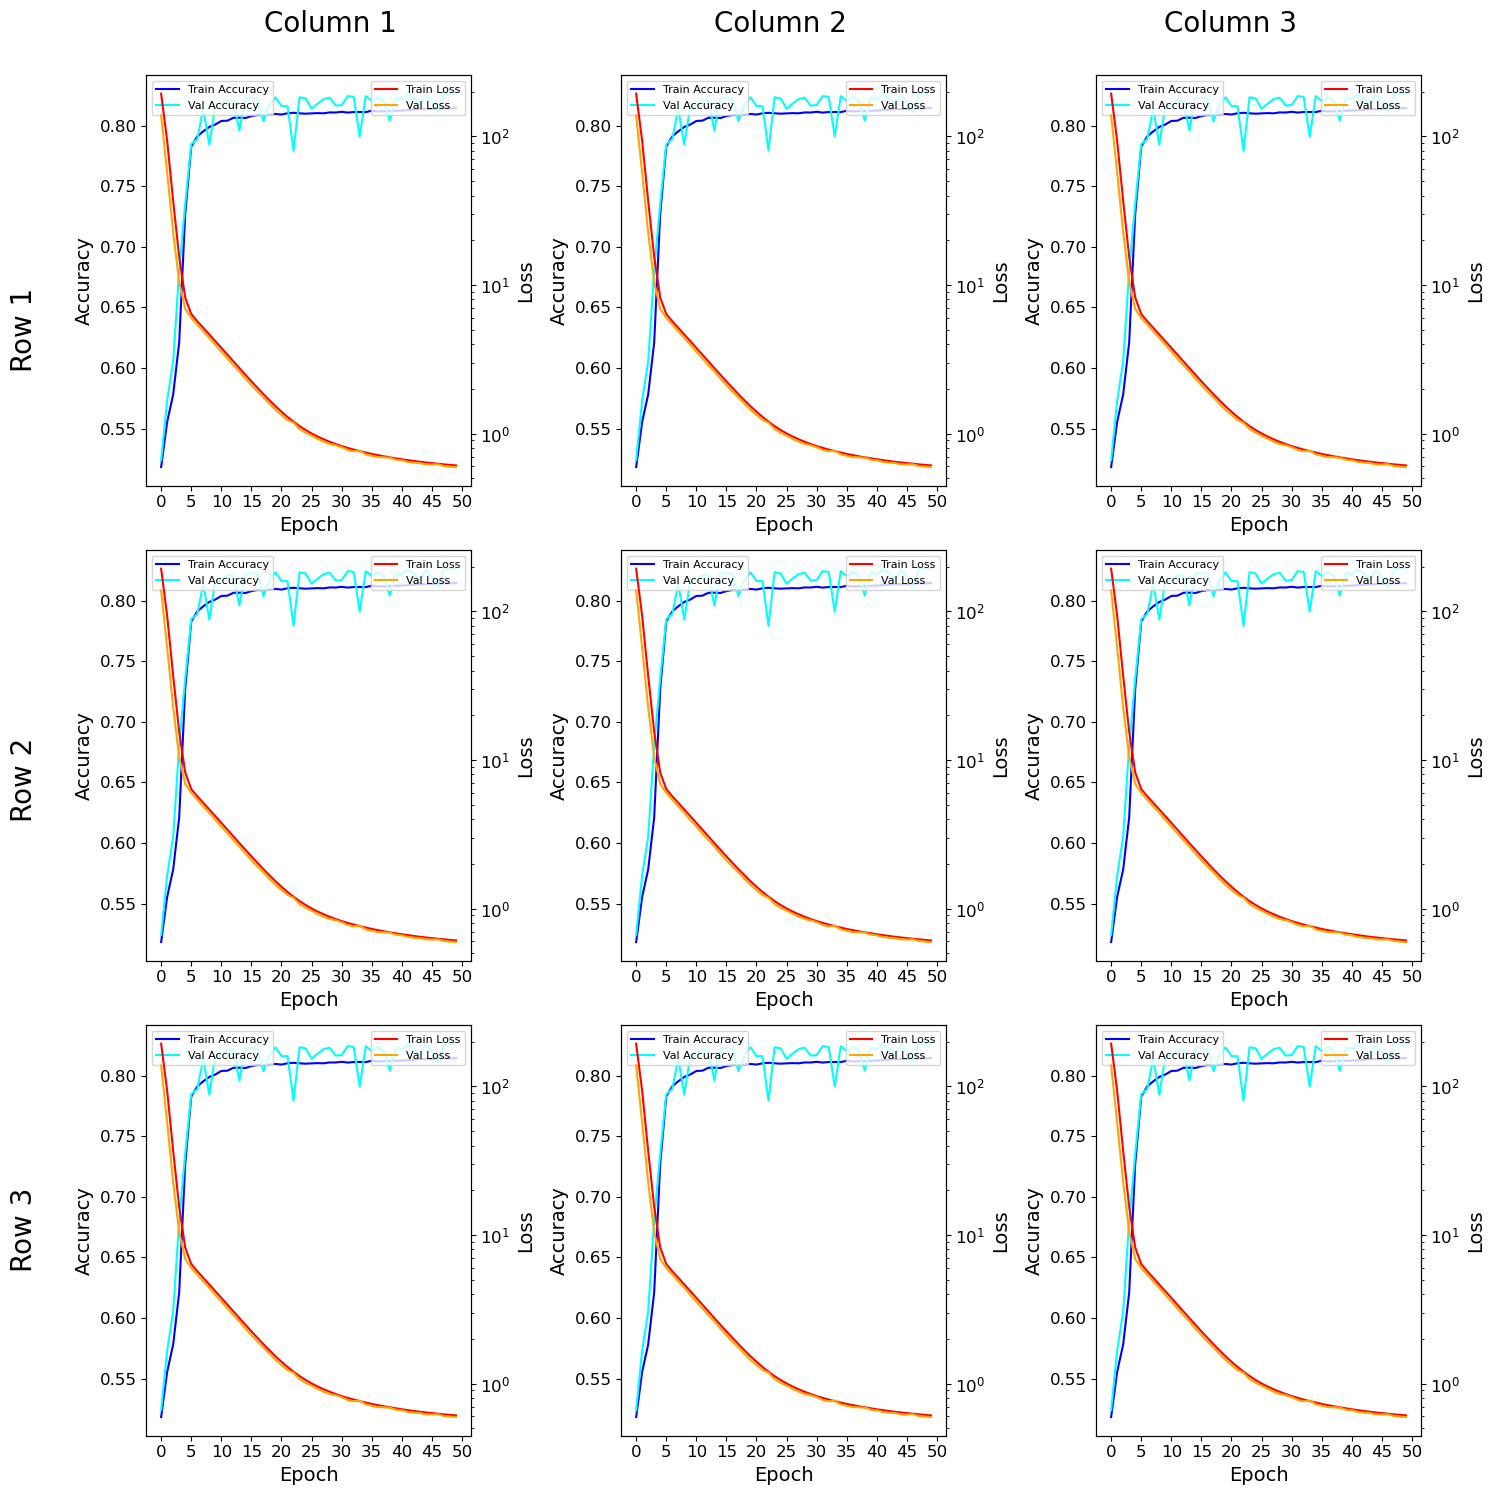

'/home/arsalan/wsu-grid/hm_jetscapeml_source/reports/figures/eloss_vgg16_net_1_fold_50_epoch_1200k_dataset_size_batch_128_no_rl_hm_srv3_cpu_24_mem_32gb/accuracy_loss_grid.png'

In [16]:
#make row and column titles
row_titles = ['Row 1', 'Row 2', 'Row 3']
col_titles = ['Column 1', 'Column 2', 'Column 3']
plot_multiple_histories_with_row_col_title (histories=[history, history, history, history, history, history, history, history, history], row_titles=row_titles, col_titles=col_titles, loss_y_scale='log')

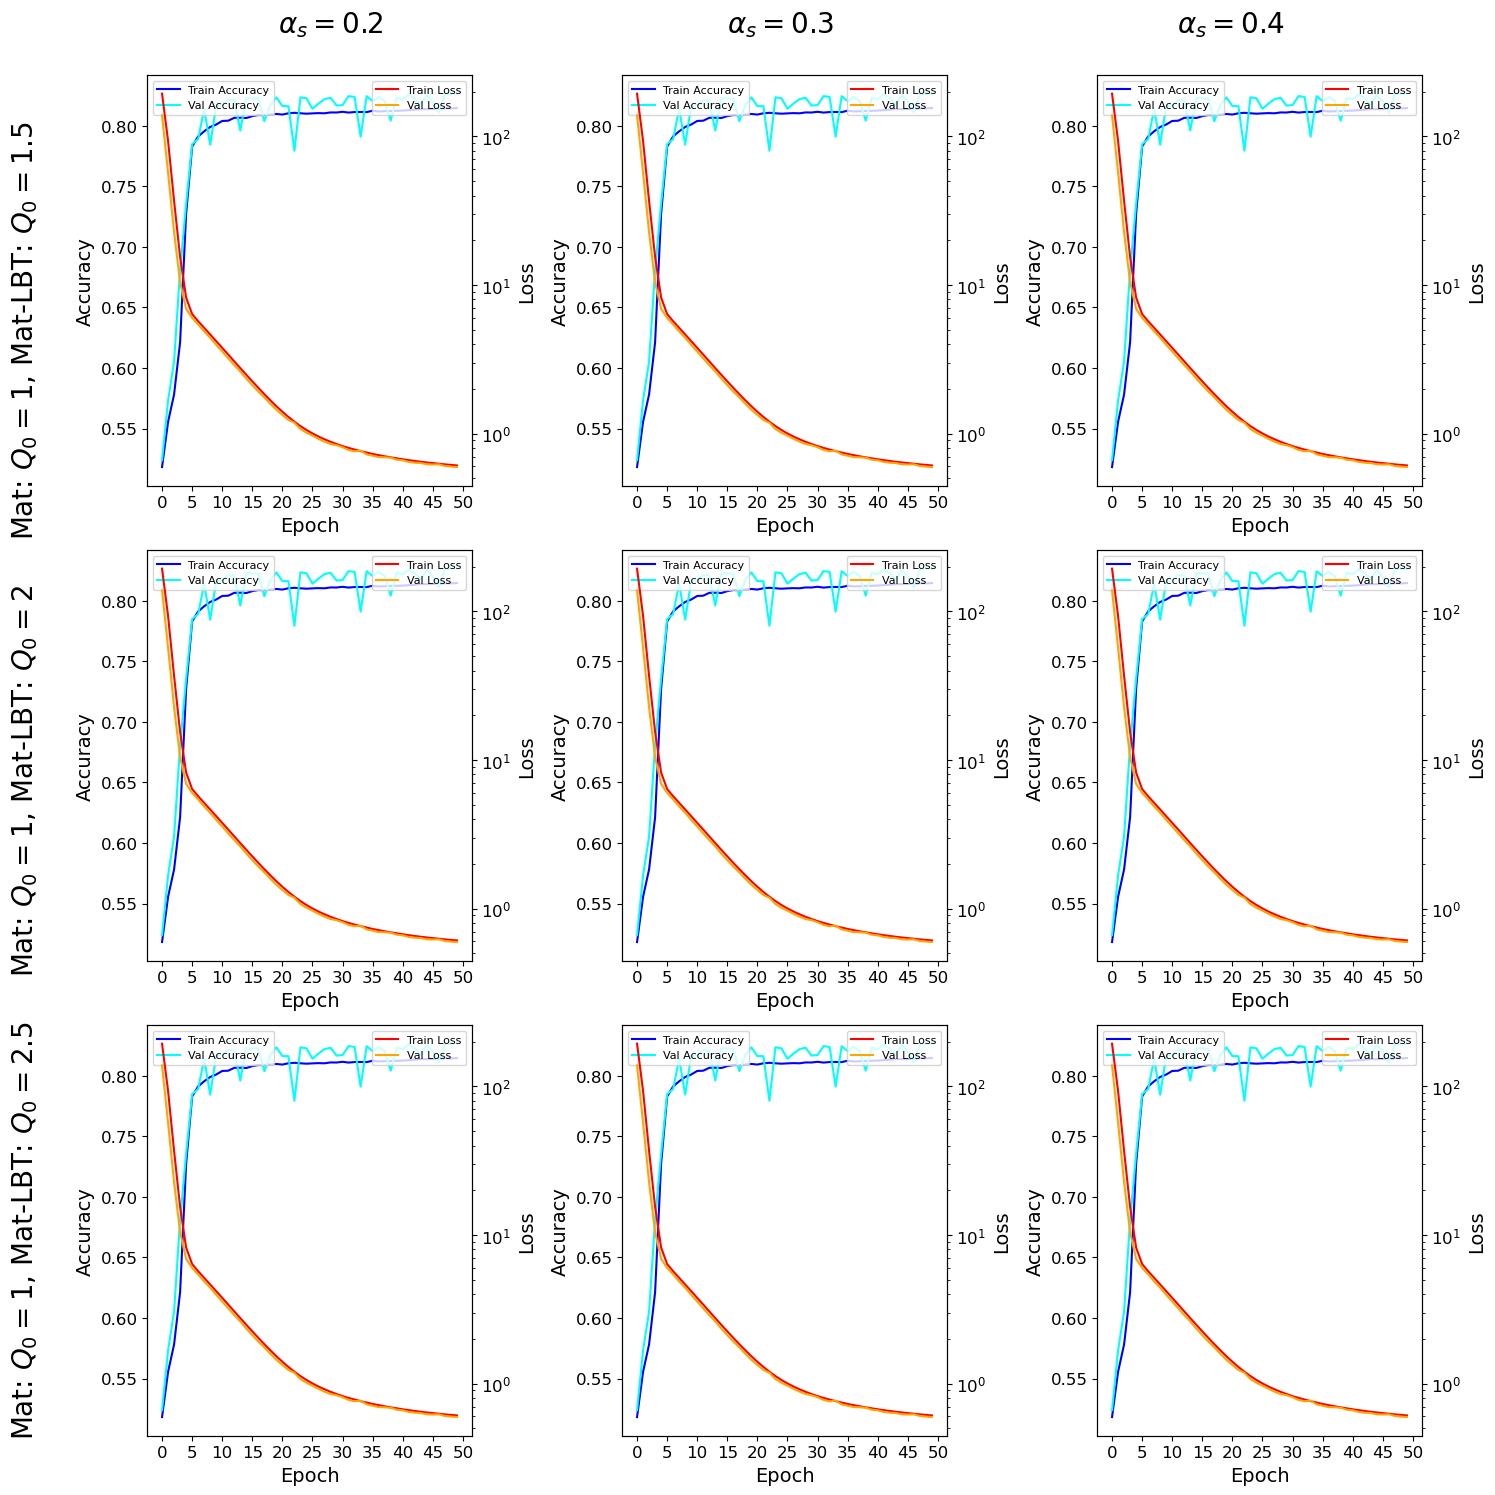

'/home/arsalan/wsu-grid/hm_jetscapeml_source/reports/figures/eloss_vgg16_net_1_fold_50_epoch_1200k_dataset_size_batch_128_no_rl_hm_srv3_cpu_24_mem_32gb/accuracy_loss_grid.png'

In [30]:
#make row and column titles
row_titles = [
    r"Mat: $Q_0=1$, Mat-LBT: $Q_0=1.5$",
    r"Mat: $Q_0=1$, Mat-LBT: $Q_0=2$",
    r"Mat: $Q_0=1$, Mat-LBT: $Q_0=2.5$"
]
col_titles = [r"$\alpha_s = 0.2$", r"$\alpha_s = 0.3$", r"$\alpha_s = 0.4$"]
plot_multiple_histories_with_row_col_title (histories=[history, history, history, history, history, history, history, history, history], row_titles=row_titles, col_titles=col_titles, loss_y_scale='log')


In [35]:
import pandas as pd

# Base path to the directory containing the history files
base_path = '~/wsu-grid/hm_jetscapeml_data/all_simulations/simulation-results-deep-model-cnn-01-1200K-config-'

# List to hold history dictionaries
histories = []

# Loop to load each file
for i in range(1, 10):
    file_path = f"{base_path}{i:02d}-epoch-50/hm_jetscape_ml_model_history.csv"
    # Load each CSV file into a DataFrame
    history_df = pd.read_csv(file_path)
    # Convert the DataFrame to a dictionary format similar to history.history
    history_dict = history_df.to_dict(orient='list')
    # Create a mock history object
    history = MockHistory(history_dict)
    # Append the dictionary to the list
    histories.append(history)

# Display a sample from one of the loaded histories to verify
print(histories[0])  # Print the first history dictionary

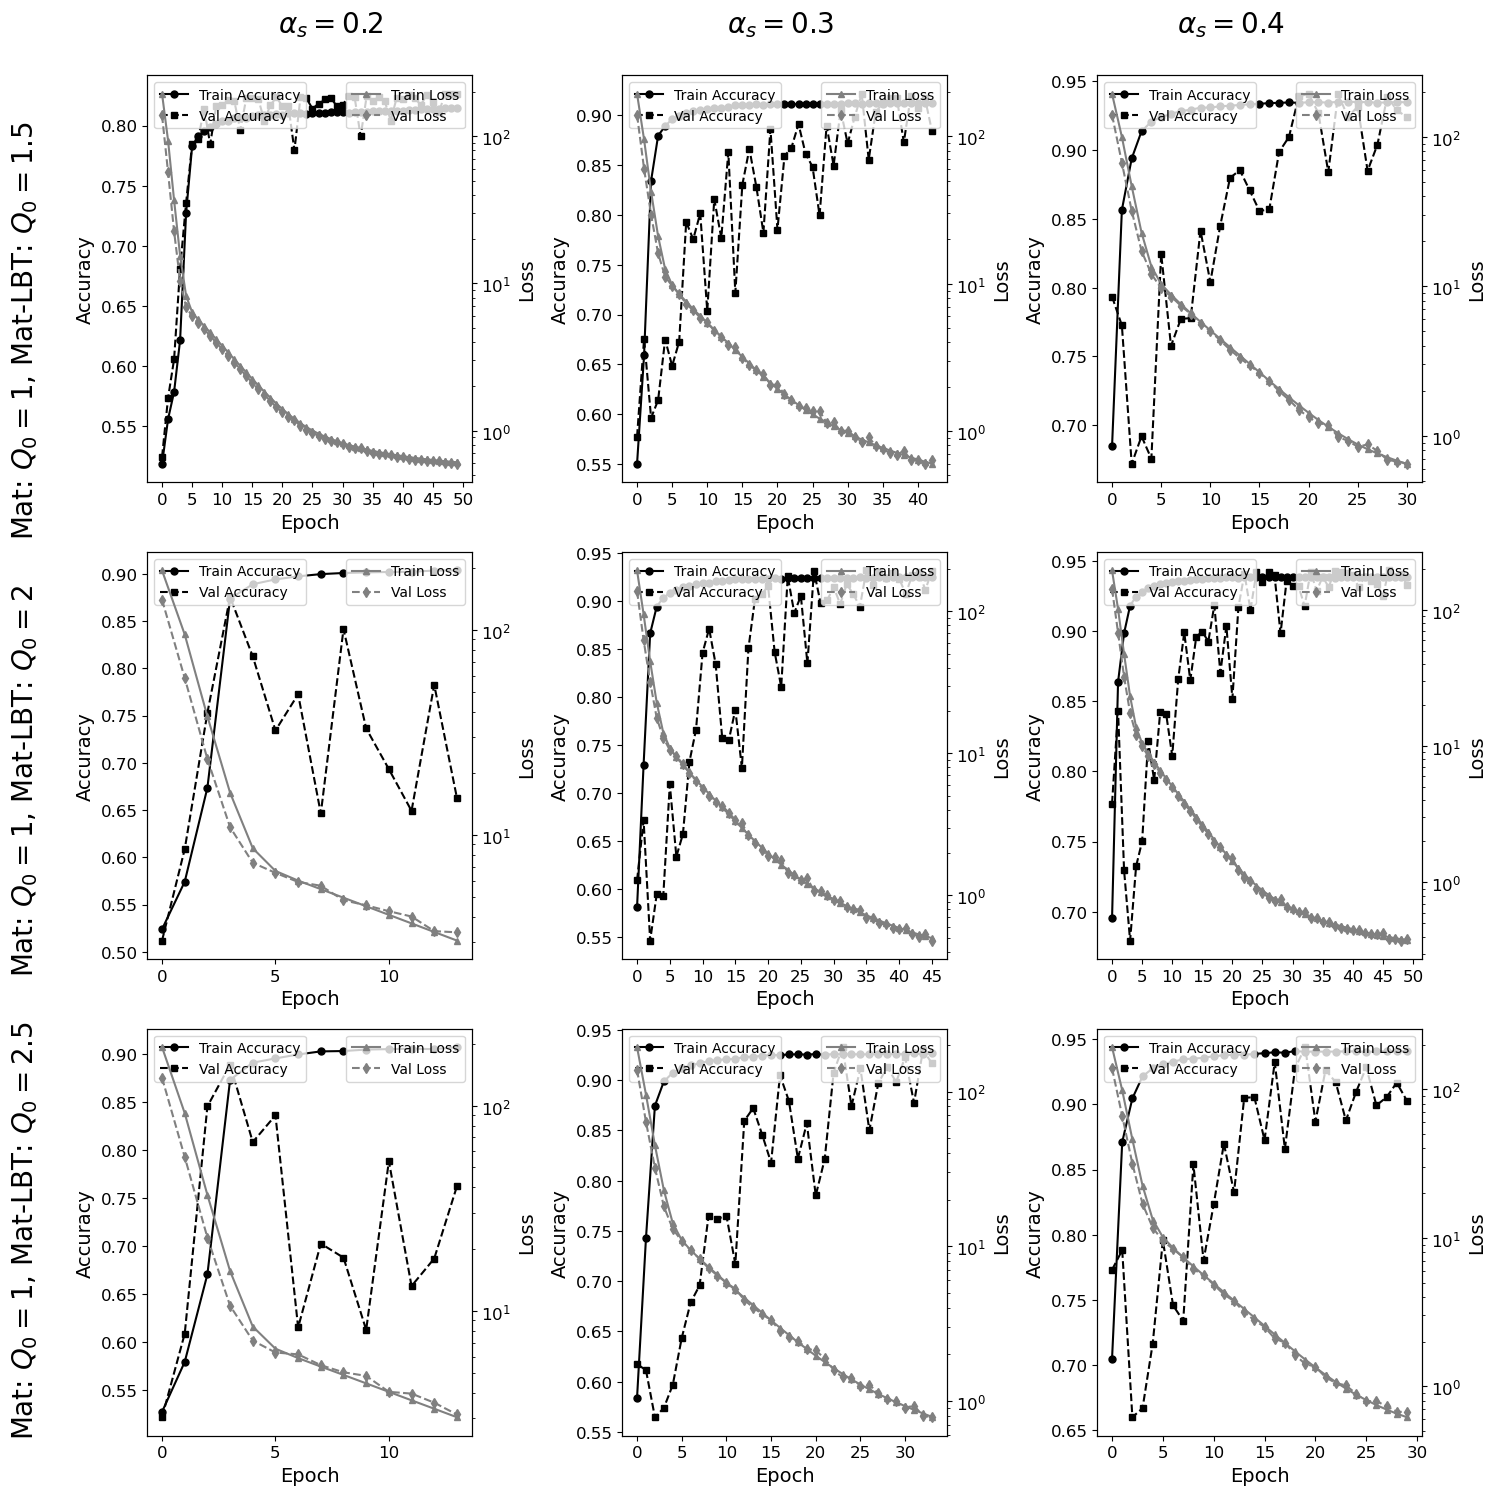

'/home/arsalan/wsu-grid/hm_jetscapeml_source/reports/figures/eloss_vgg16_net_1_fold_50_epoch_1200k_dataset_size_batch_128_no_rl_hm_srv3_cpu_24_mem_32gb/accuracy_loss_grid_bw.png'

In [58]:
#make row and column titles
row_titles = [
    r"Mat: $Q_0=1$, Mat-LBT: $Q_0=1.5$",
    r"Mat: $Q_0=1$, Mat-LBT: $Q_0=2$",
    r"Mat: $Q_0=1$, Mat-LBT: $Q_0=2.5$"
]
col_titles = [r"$\alpha_s = 0.2$", r"$\alpha_s = 0.3$", r"$\alpha_s = 0.4$"]
plot_multiple_histories_with_row_col_title (histories=histories, row_titles=row_titles, col_titles=col_titles, loss_y_scale='log')


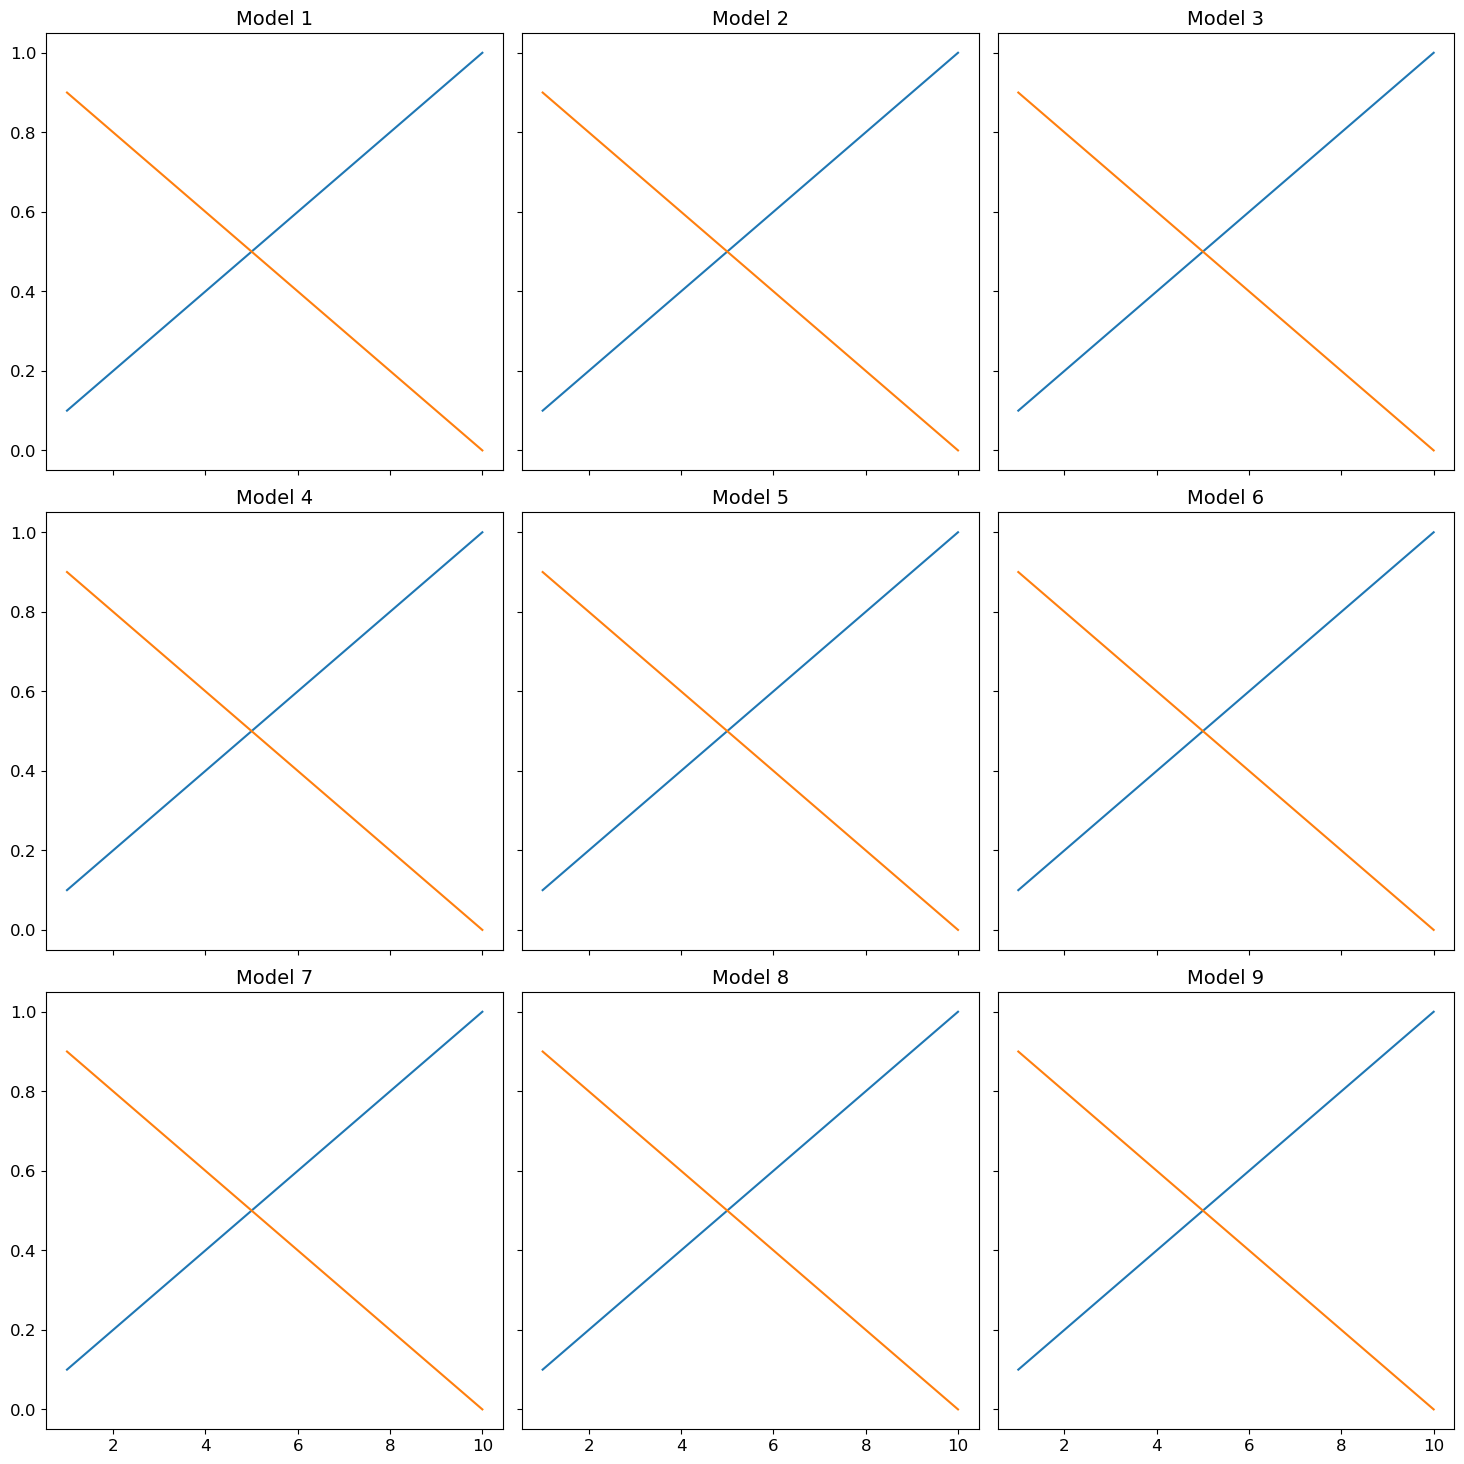

In [6]:
import matplotlib.pyplot as plt

# Sample data for illustration (replace with your data)
epochs = range(1, 11)
acc_data = [0.1 * i for i in epochs]
loss_data = [1 - 0.1 * i for i in epochs]

# Create a 3x3 grid of plots
fig, axes = plt.subplots(3, 3, figsize=(15, 15))  # Adjust figsize to control overall size

# Increase font size for readability
plt.rcParams.update({
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
})

for i in range(3):
    for j in range(3):
        ax = axes[i, j]
        ax.plot(epochs, acc_data, label='Accuracy')
        ax.plot(epochs, loss_data, label='Loss')
        ax.set_title(f'Model {i*3 + j + 1}')
        
        # Hide x and y axis labels for inner plots to reduce clutter
        if i < 2:  # Hide x labels except for bottom row
            ax.set_xticklabels([])
        if j > 0:  # Hide y labels except for first column
            ax.set_yticklabels([])

        # Optionally adjust the aspect ratio to make it fit better
        ax.set_aspect('auto')

# Use tight_layout with padding adjustments to fill space
plt.tight_layout(pad=2.0, w_pad=1.0, h_pad=1.0)  # Adjust padding as needed

plt.show()

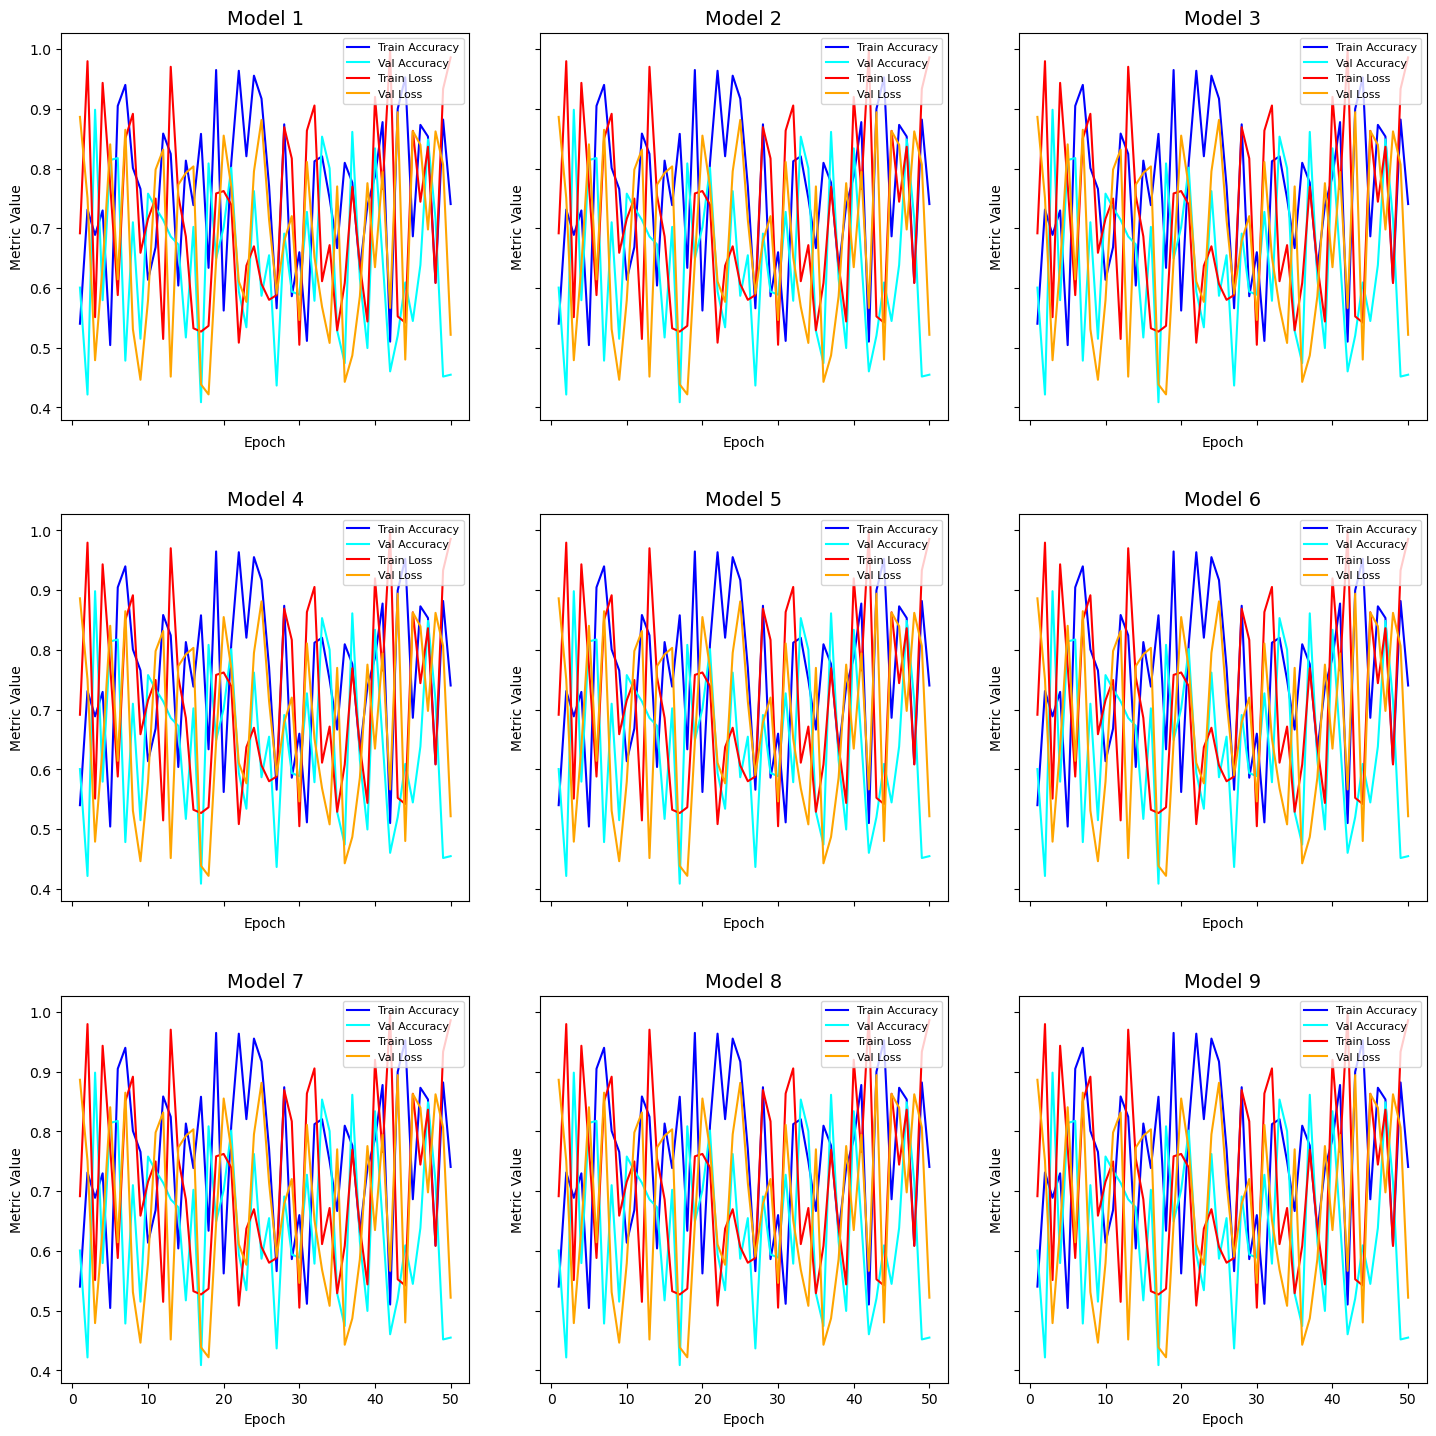

In [7]:
import matplotlib.pyplot as plt
import numpy as np

# Sample data for illustration (replace with your actual data)
epochs = np.arange(1, 51)
acc_data = np.random.uniform(0.5, 1.0, size=50)  # Example accuracy data
val_acc_data = np.random.uniform(0.4, 0.9, size=50)  # Example validation accuracy data
loss_data = np.random.uniform(0.5, 1.0, size=50)  # Example loss data
val_loss_data = np.random.uniform(0.4, 0.9, size=50)  # Example validation loss data

# Create a 3x3 grid of plots
fig, axes = plt.subplots(3, 3, figsize=(15, 15))  # Adjust figsize as needed

for i in range(3):
    for j in range(3):
        ax = axes[i, j]
        
        # Plot accuracy and validation accuracy
        ax.plot(epochs, acc_data, label='Train Accuracy', color='blue')
        ax.plot(epochs, val_acc_data, label='Val Accuracy', color='cyan')
        
        # Plot loss and validation loss
        ax.plot(epochs, loss_data, label='Train Loss', color='red')
        ax.plot(epochs, val_loss_data, label='Val Loss', color='orange')
        
        # Set titles and labels
        ax.set_title(f'Model {i*3 + j + 1}', fontsize=14)
        ax.set_xlabel('Epoch', fontsize=10)
        ax.set_ylabel('Metric Value', fontsize=10)
        
        # Add a legend for clarity
        ax.legend(loc='upper right', fontsize=8)
        
        # Optionally, remove x and y labels for inner plots to reduce clutter
        if i < 2:
            ax.set_xticklabels([])
        if j > 0:
            ax.set_yticklabels([])

# Adjust layout to fill the entire figure
plt.tight_layout(pad=3.0)

plt.show()

In [8]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.gridspec import GridSpec

# Sample data for illustration (replace with your actual data)
epochs = np.arange(1, 51)
acc_data = np.random.uniform(0.5, 1.0, size=50)  # Example accuracy data
val_acc_data = np.random.uniform(0.4, 0.9, size=50)  # Example validation accuracy data
loss_data = np.random.uniform(0.5, 1.0, size=50)  # Example loss data
val_loss_data = np.random.uniform(0.4, 0.9, size=50)  # Example validation loss data

# Create a 3x3 grid of subplots, with each cell containing two stacked plots for accuracy and loss
fig = plt.figure(figsize=(18, 18))
outer_grid = GridSpec(3, 3, wspace=0.3, hspace=0.3)

for i in range(9):
    # Create an inner grid with 2 rows for each cell in the 3x3 outer grid
    inner_grid = GridSpec(2, 1, subplot_spec=outer_grid[i], hspace=0.15)
    
    # Accuracy plot
    ax1 = fig.add_subplot(inner_grid[0])
    ax1.plot(epochs, acc_data, label='Train Accuracy', color='blue')
    ax1.plot(epochs, val_acc_data, label='Val Accuracy', color='cyan')
    ax1.set_title(f'Model {i + 1} - Accuracy', fontsize=14)
    ax1.set_ylabel('Accuracy')
    ax1.legend(loc='upper right', fontsize=8)

    # Loss plot
    ax2 = fig.add_subplot(inner_grid[1])
    ax2.plot(epochs, loss_data, label='Train Loss', color='red')
    ax2.plot(epochs, val_loss_data, label='Val Loss', color='orange')
    ax2.set_title(f'Model {i + 1} - Loss', fontsize=14)
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Loss')
    ax2.legend(loc='upper right', fontsize=8)

# Display the figure
plt.show()


TypeError: GridSpec.__init__() got an unexpected keyword argument 'subplot_spec'

<Figure size 1800x1800 with 0 Axes>

/tmp/ipykernel_140251/4158466104.py:37: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


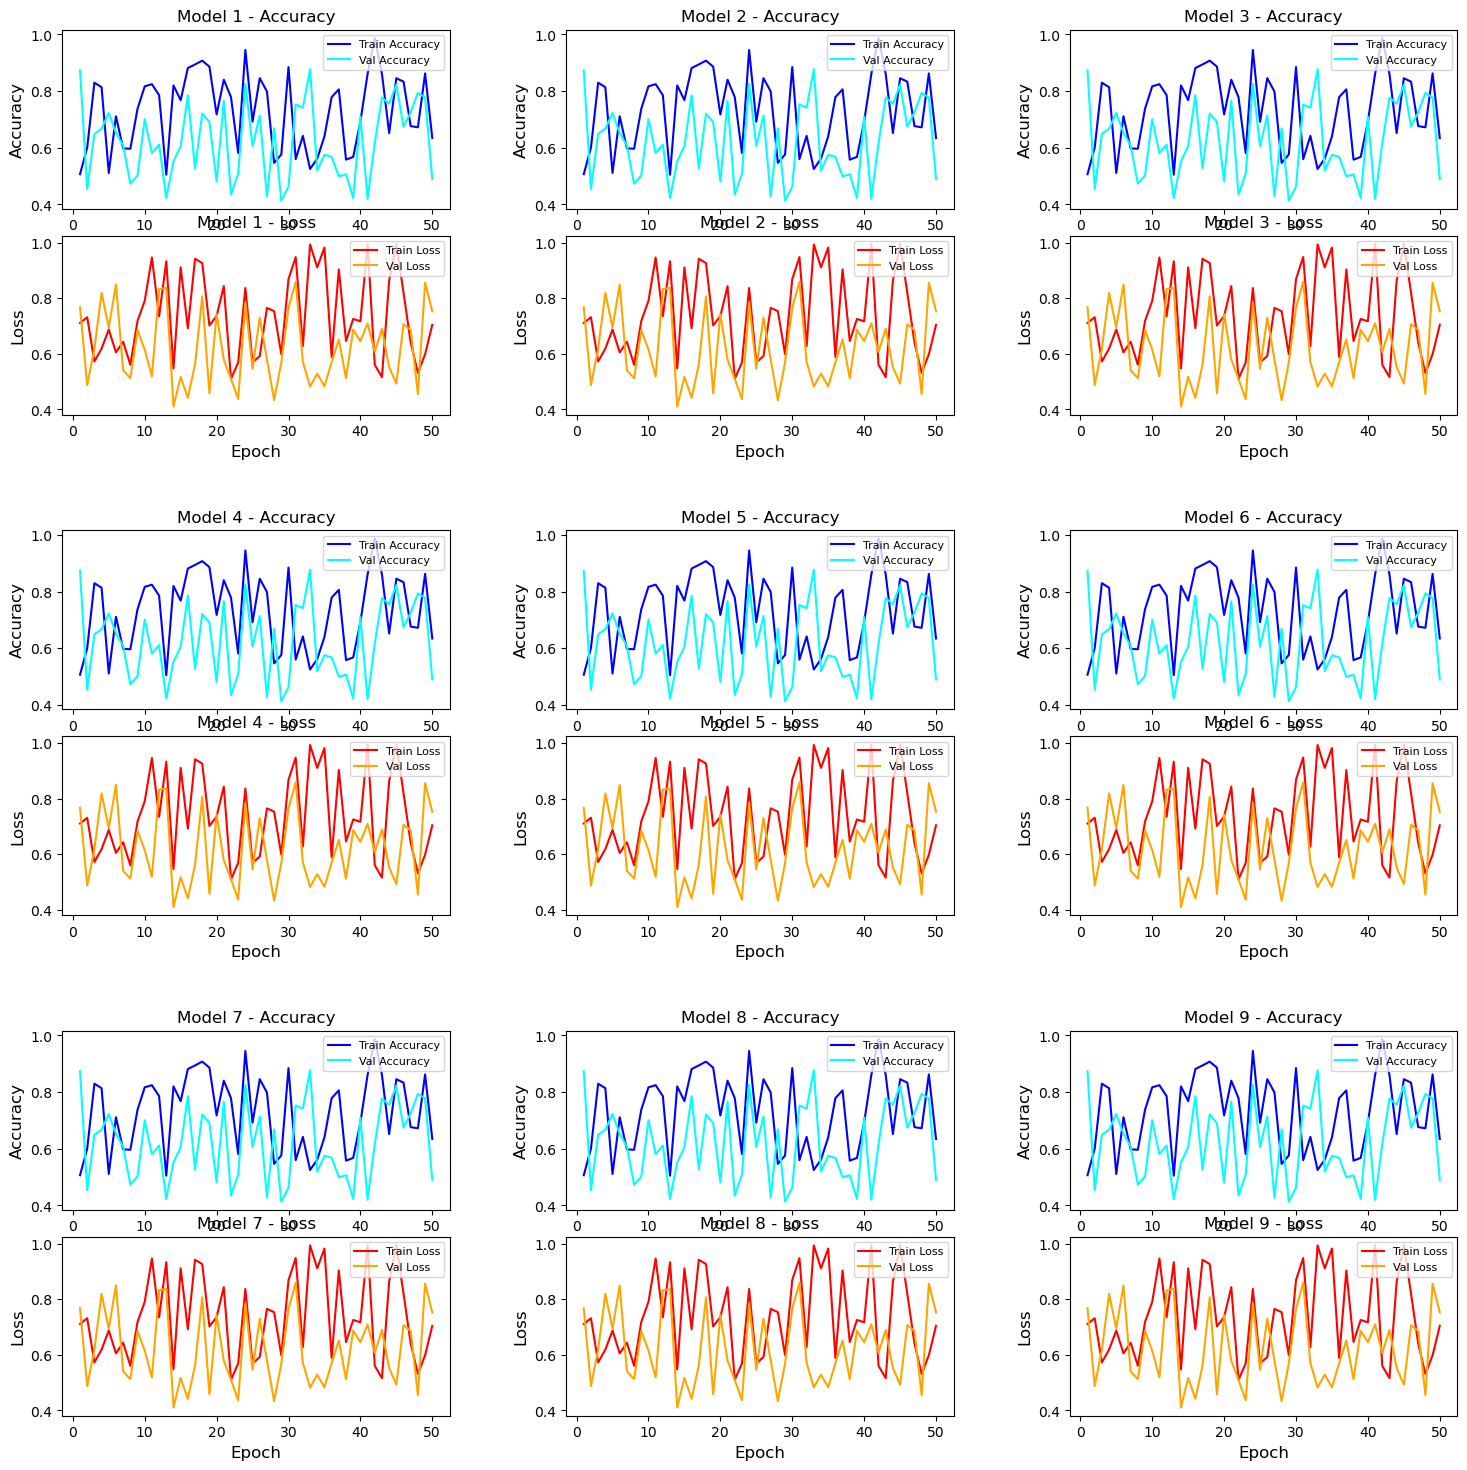

In [10]:
import matplotlib.pyplot as plt
import numpy as np

# Sample data for illustration (replace with your actual data)
epochs = np.arange(1, 51)
acc_data = np.random.uniform(0.5, 1.0, size=50)  # Example accuracy data
val_acc_data = np.random.uniform(0.4, 0.9, size=50)  # Example validation accuracy data
loss_data = np.random.uniform(0.5, 1.0, size=50)  # Example loss data
val_loss_data = np.random.uniform(0.4, 0.9, size=50)  # Example validation loss data

# Create the outer 3x3 grid
fig = plt.figure(figsize=(18, 18))
outer_grid = fig.add_gridspec(3, 3, wspace=0.3, hspace=0.3)

for i in range(3):
    for j in range(3):
        # Create an inner 2-row grid within each outer grid cell
        inner_grid = outer_grid[i, j].subgridspec(2, 1, hspace=0.15)
        
        # Accuracy plot
        ax1 = fig.add_subplot(inner_grid[0])
        ax1.plot(epochs, acc_data, label='Train Accuracy', color='blue')
        ax1.plot(epochs, val_acc_data, label='Val Accuracy', color='cyan')
        ax1.set_title(f'Model {i*3 + j + 1} - Accuracy', fontsize=12)
        ax1.set_ylabel('Accuracy')
        ax1.legend(loc='upper right', fontsize=8)

        # Loss plot
        ax2 = fig.add_subplot(inner_grid[1])
        ax2.plot(epochs, loss_data, label='Train Loss', color='red')
        ax2.plot(epochs, val_loss_data, label='Val Loss', color='orange')
        ax2.set_title(f'Model {i*3 + j + 1} - Loss', fontsize=12)
        ax2.set_xlabel('Epoch')
        ax2.set_ylabel('Loss')
        ax2.legend(loc='upper right', fontsize=8)

plt.tight_layout()

# Display the figure
plt.show()
